# Logistic regression random restarts

This is the PyMC tutorial simulated logistic regression example, run in PyMC.

We compare 1 MC sample and 100 MC samples over 10 random restarts. The reference lines are the best variational approximation found across all method restarts.


In [2]:
import os
from pathlib import Path
os.environ.setdefault("PYTENSOR_FLAGS", "base_compiledir=/tmp/pytensor")
import sys

sys.path.append(os.path.abspath("../.."))

import pymc as pm
import pytensor
if os.environ.get("SIMPLEVI_PYTENSOR_CXX"):
    pytensor.config.cxx = os.environ["SIMPLEVI_PYTENSOR_CXX"]

from modulars.pymc_rr_test import run_pymc_VI, run_single_seed_pymc_VI

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import gc
from tqdm.notebook import tqdm

from modulars.logistic_regression import (
    build_pymc_logistic_regression_model,
    load_logistic_regression_data,
    plot_logistic_regression_selected_coeffs,
)
from modulars.plot_rr import plot_some_dims_multid
from modulars.utils import apply_traj_transform_multid, save_to_csv

data = load_logistic_regression_data()
labels = data["labels"]
dim = len(labels)

print(f"N observations: {len(data['y'])}")
print(f"N training observations: {len(data['y_train'])}")
print(f"N test observations: {len(data['y_test'])}")
print(f"Latent VI dimension: {dim}")
print(labels)


N observations: 250
N training observations: 175
N test observations: 75
Latent VI dimension: 4
['Intercept', 'x1', 'x2', 'x1:x2']


In [3]:
RUN_MODE = "full"  # "quick" or "full"

RUN_CONFIGS = {
    "quick": {"max_iters": 250, "n_restarts": 1, "n_particles": 100, "track_every": 10},
    "full": {"max_iters": 40_000, "n_restarts": 5, "n_particles": 100, "track_every": 10},
}

run_config = RUN_CONFIGS[RUN_MODE]
max_iters = run_config["max_iters"]
n_restarts = run_config["n_restarts"]
n_particles = run_config["n_particles"]
track_every = run_config["track_every"]

results_dir = Path("results")
results_dir.mkdir(exist_ok=True)

run_config


{'max_iters': 40000, 'n_restarts': 5, 'n_particles': 100, 'track_every': 10}

In [4]:
def run_model(n_mc_samples=1, optimizer="default", seed=1):
    model = build_pymc_logistic_regression_model(data)
    return run_pymc_VI(
        model,
        n_mc_samples=n_mc_samples,
        n_iters=max_iters,
        optimizer=optimizer,
        seed=seed,
        SINGLE_DIM=False,
        track_every=track_every,
        track_cov=False,
    )


In [4]:
results = []
for seed in tqdm(range(n_restarts)):
    single_means, single_stds = run_model(
        n_mc_samples=1,
        seed=seed,
        optimizer="default",
    )
    multi_means, multi_stds = run_model(
        n_mc_samples=100,
        seed=seed + 1000,
        optimizer="default",
    )
    results.append([single_means, single_stds, multi_means, multi_stds])


  0%|          | 0/5 [00:00<?, ?it/s]

Finished [100%]: Average Loss = 66.522
Finished [100%]: Average Loss = 66.495
Finished [100%]: Average Loss = 66.51
Finished [100%]: Average Loss = 66.499
Finished [100%]: Average Loss = 66.542
Finished [100%]: Average Loss = 66.499
Finished [100%]: Average Loss = 66.602
Finished [100%]: Average Loss = 66.494
Finished [100%]: Average Loss = 66.546
Finished [100%]: Average Loss = 66.497


In [5]:
save_to_csv(results_dir / "pymc_default_raw_restarts.csv", results)


In [6]:
results_adam = []
for seed in tqdm(range(n_restarts)):
    adam_single_means, adam_single_stds = run_model(
        n_mc_samples=1,
        seed=seed,
        optimizer="adam",
    )
    adam_multi_means, adam_multi_stds = run_model(
        n_mc_samples=100,
        seed=seed + 1000,
        optimizer="adam",
    )
    results_adam.append([adam_single_means, adam_single_stds, adam_multi_means, adam_multi_stds])


  0%|          | 0/5 [00:00<?, ?it/s]

Finished [100%]: Average Loss = 66.492
Finished [100%]: Average Loss = 66.495
Finished [100%]: Average Loss = 66.48
Finished [100%]: Average Loss = 66.5
Finished [100%]: Average Loss = 66.49
Finished [100%]: Average Loss = 66.5
Finished [100%]: Average Loss = 66.554
Finished [100%]: Average Loss = 66.494
Finished [100%]: Average Loss = 66.504
Finished [100%]: Average Loss = 66.497


In [7]:
save_to_csv(results_dir / "pymc_adam_raw_restarts.csv", results_adam)


In [8]:
single_means, single_stds, multi_means, multi_stds = apply_traj_transform_multid(results)
adam_single_means, adam_single_stds, adam_multi_means, adam_multi_stds = apply_traj_transform_multid(results_adam)


print(single_means.shape, single_stds.shape, multi_means.shape, multi_stds.shape)


  0%|          | 0/5 [00:00<?, ?it/s]

  0%|          | 0/5 [00:00<?, ?it/s]

(5, 4000, 4) (5, 4000, 4) (5, 4000, 4) (5, 4000, 4)


In [9]:
save_to_csv(
    results_dir / "pymc_default_processed_restarts.csv",
    [(single_means, single_stds, multi_means, multi_stds)],
)
save_to_csv(
    results_dir / "pymc_adam_processed_restarts.csv",
    [(adam_single_means, adam_single_stds, adam_multi_means, adam_multi_stds)],
)

del results, results_adam
gc.collect()



53

In [5]:
reference_file = Path("best_variational_reference.csv")
if not reference_file.exists():
    raise FileNotFoundError(
        "Run compute_best_reference.py after generating processed restart files."
    )

best_reference = pd.read_csv(reference_file)
reference_means = {
    row["parameter"]: [(float(row["mean"]), "best variational approximation")]
    for _, row in best_reference.iterrows()
}
reference_stds = {
    row["parameter"]: [(float(row["sd"]), "best variational approximation")]
    for _, row in best_reference.iterrows()
}
best_reference


best_mean = best_reference["mean"].to_numpy()
best_std = best_reference["sd"].to_numpy()


In [24]:
from modulars.utils import load_from_csv
processed_results = load_from_csv(results_dir / "pymc_default_processed_restarts.csv")
single_means, single_stds, multi_means, multi_stds = processed_results[0]


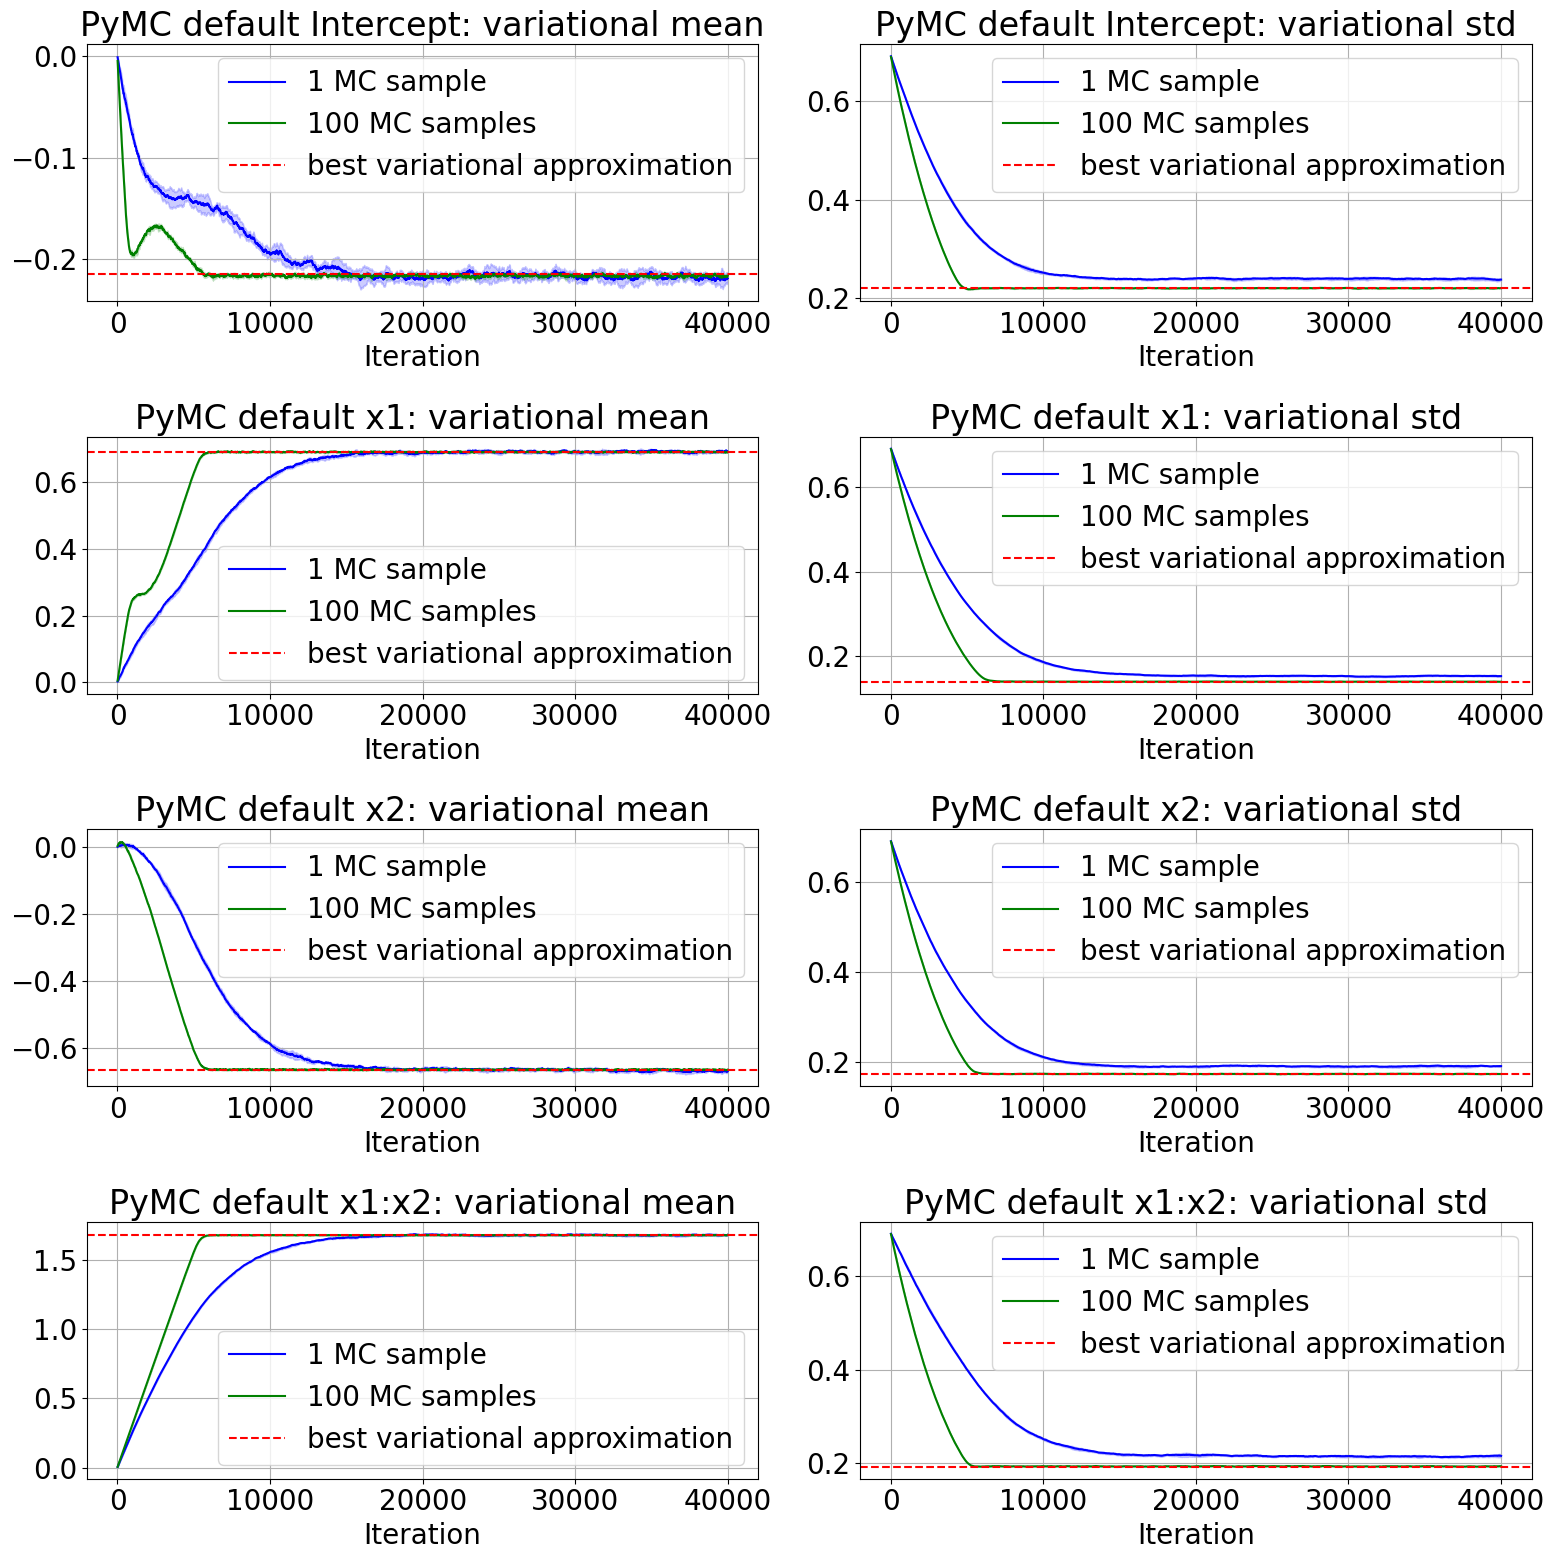

In [25]:
plot_logistic_regression_selected_coeffs(
    single_means, single_stds, multi_means, multi_stds,
    labels=labels,
    title_prefix="PyMC default ",
    reference_means=reference_means,
    reference_stds=reference_stds,
    iteration_stride=track_every
)


In [33]:
import importlib
import modulars.logistic_regression
importlib.reload(modulars.logistic_regression)

<module 'modulars.logistic_regression' from 'modulars/logistic_regression.py'>

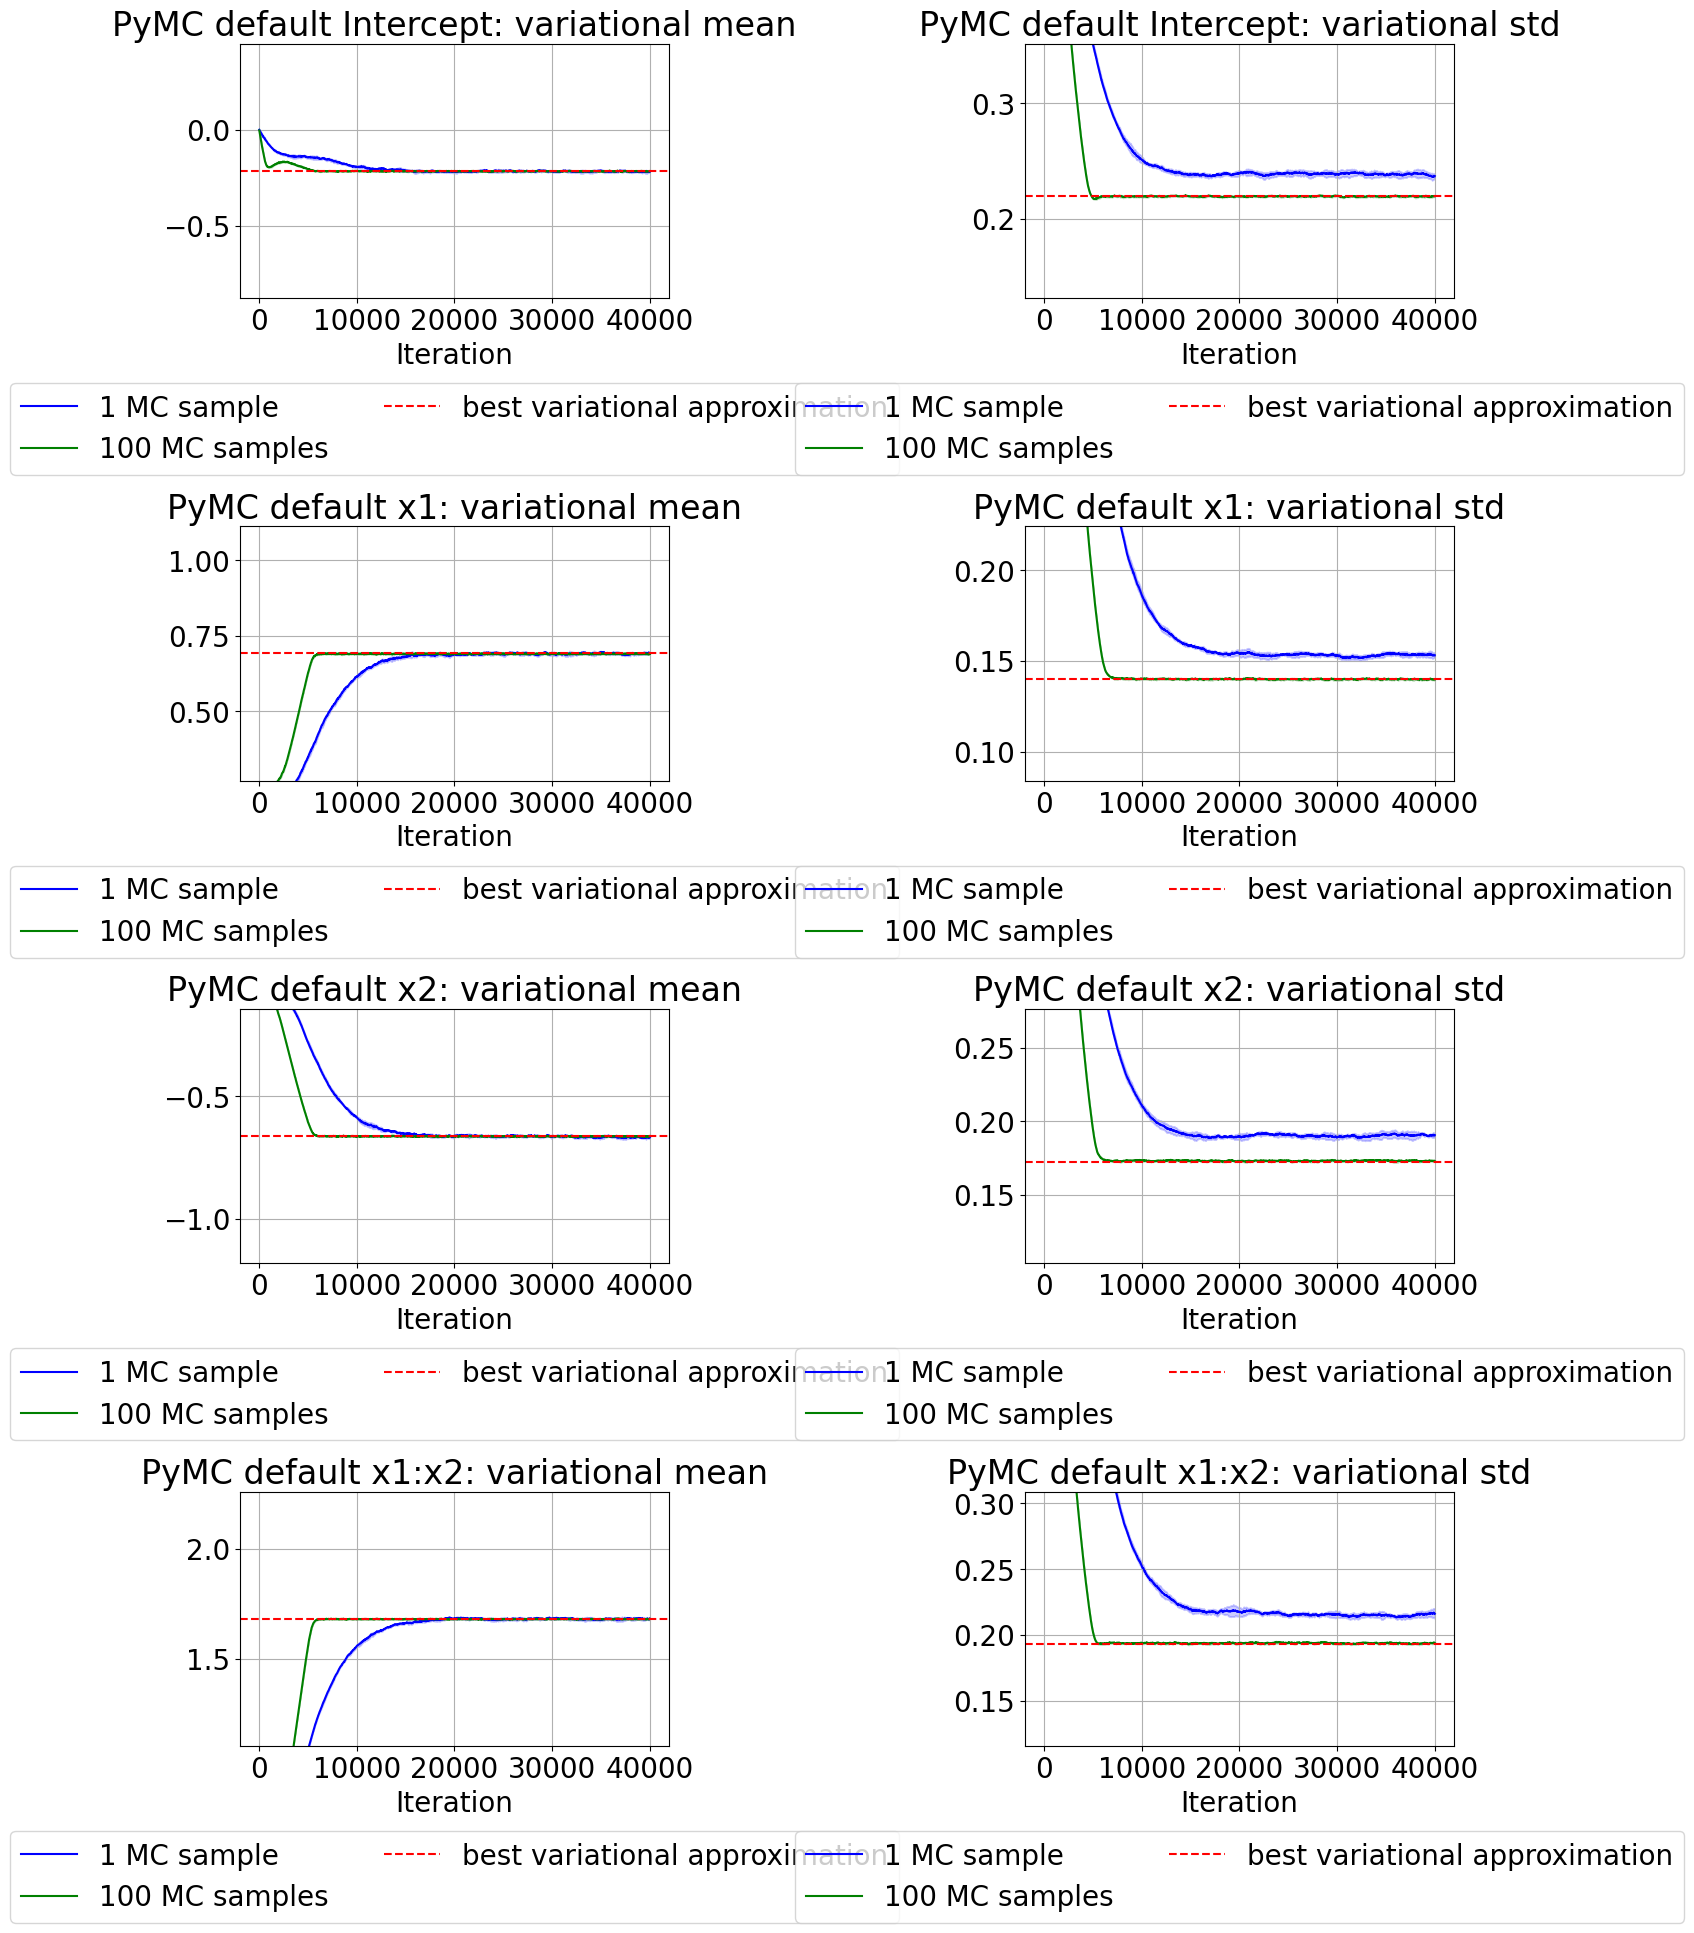

In [34]:
modulars.logistic_regression.plot_logistic_regression_selected_coeffs_zoomed(
    single_means, single_stds, multi_means, multi_stds,
    labels=labels,
    title_prefix="PyMC default ",
    reference_means=reference_means,
    reference_stds=reference_stds,
    iteration_stride=track_every
)

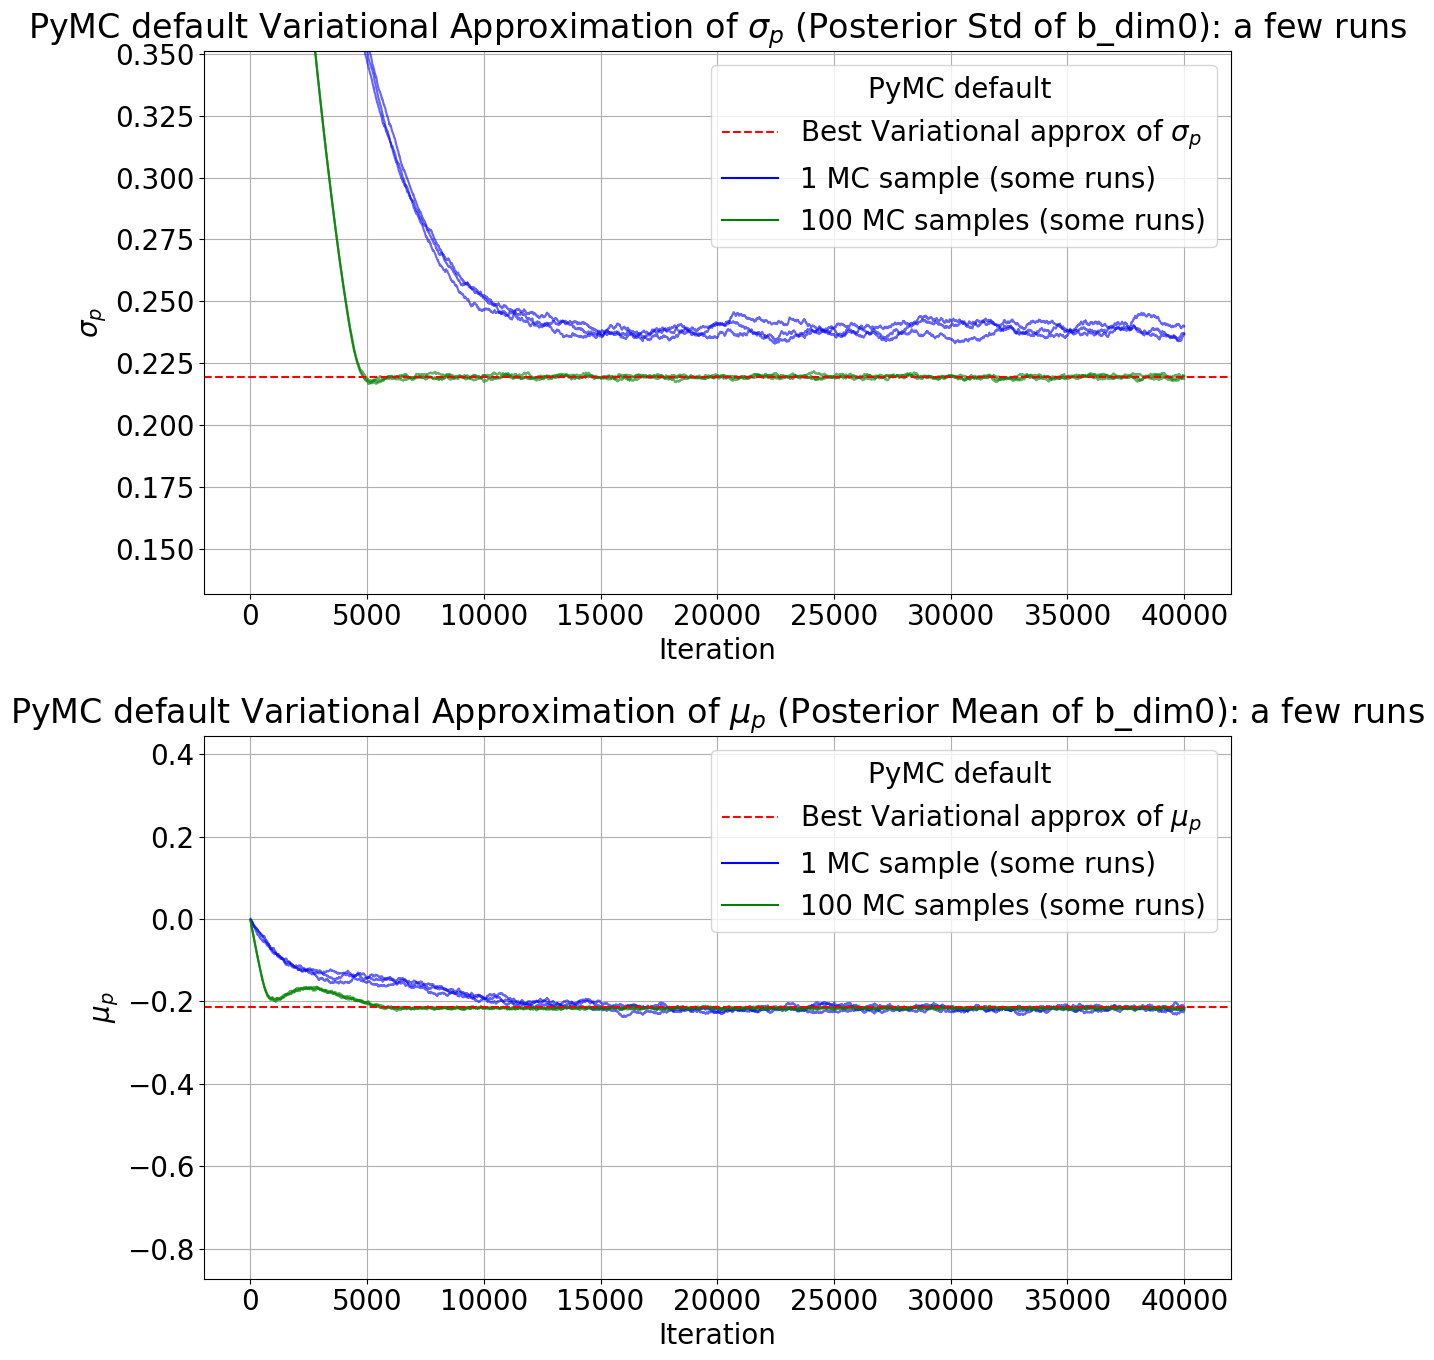

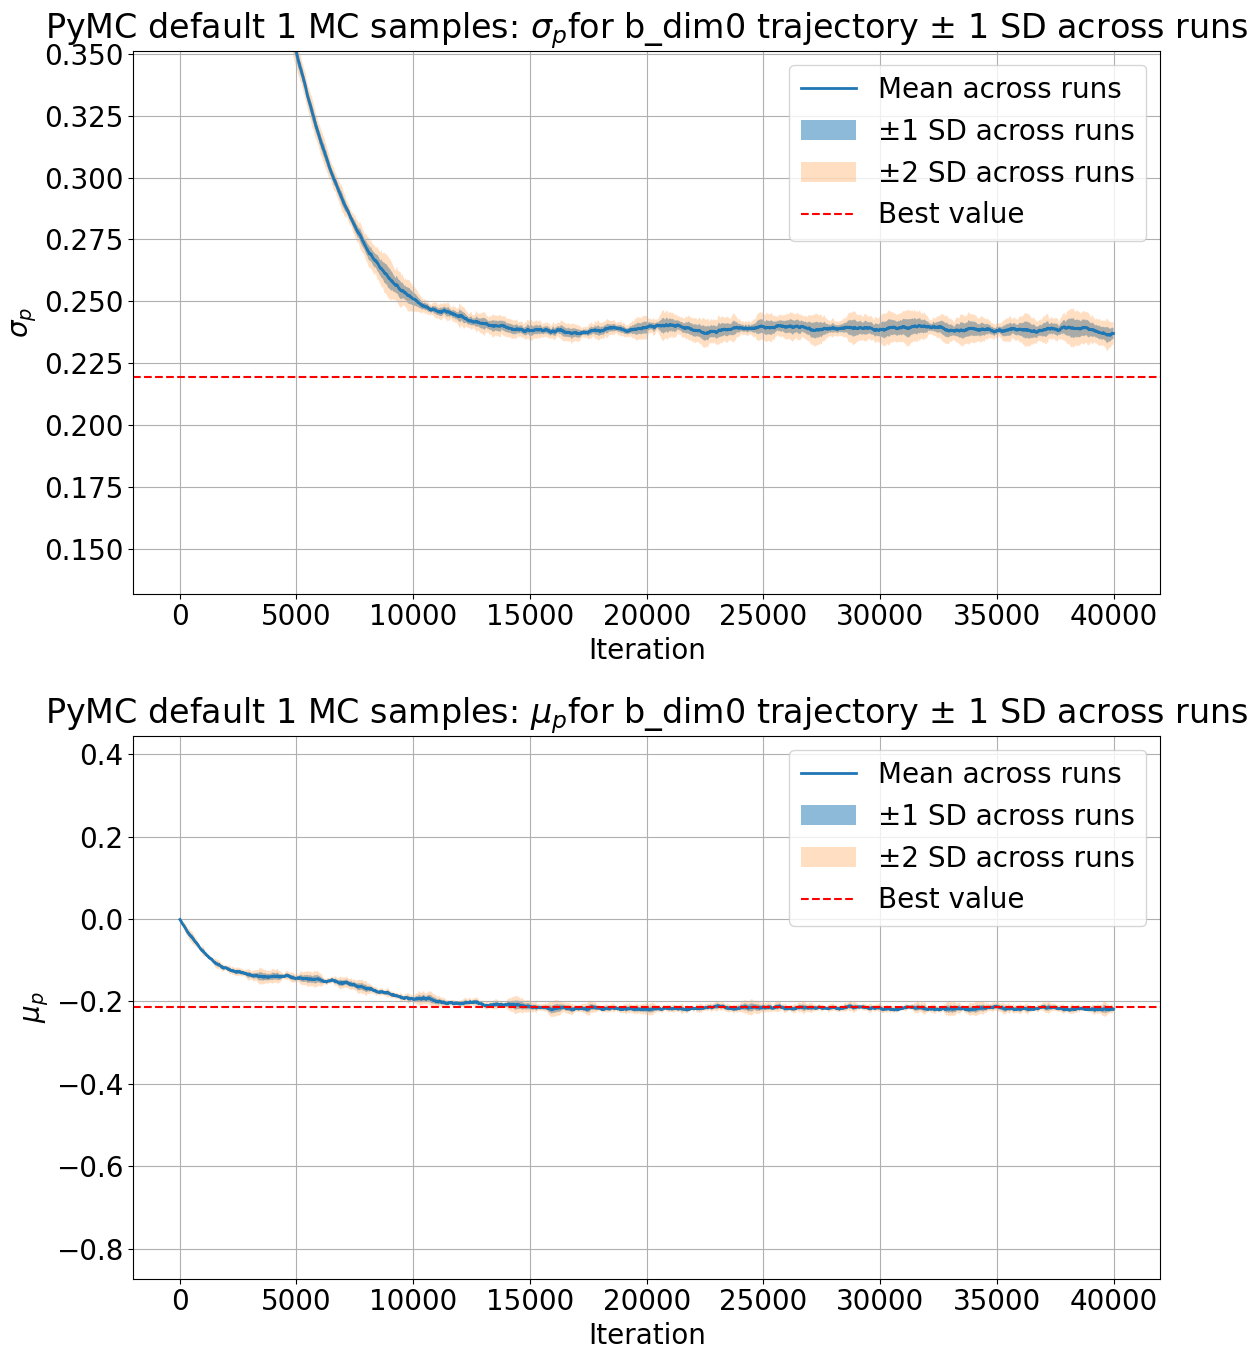

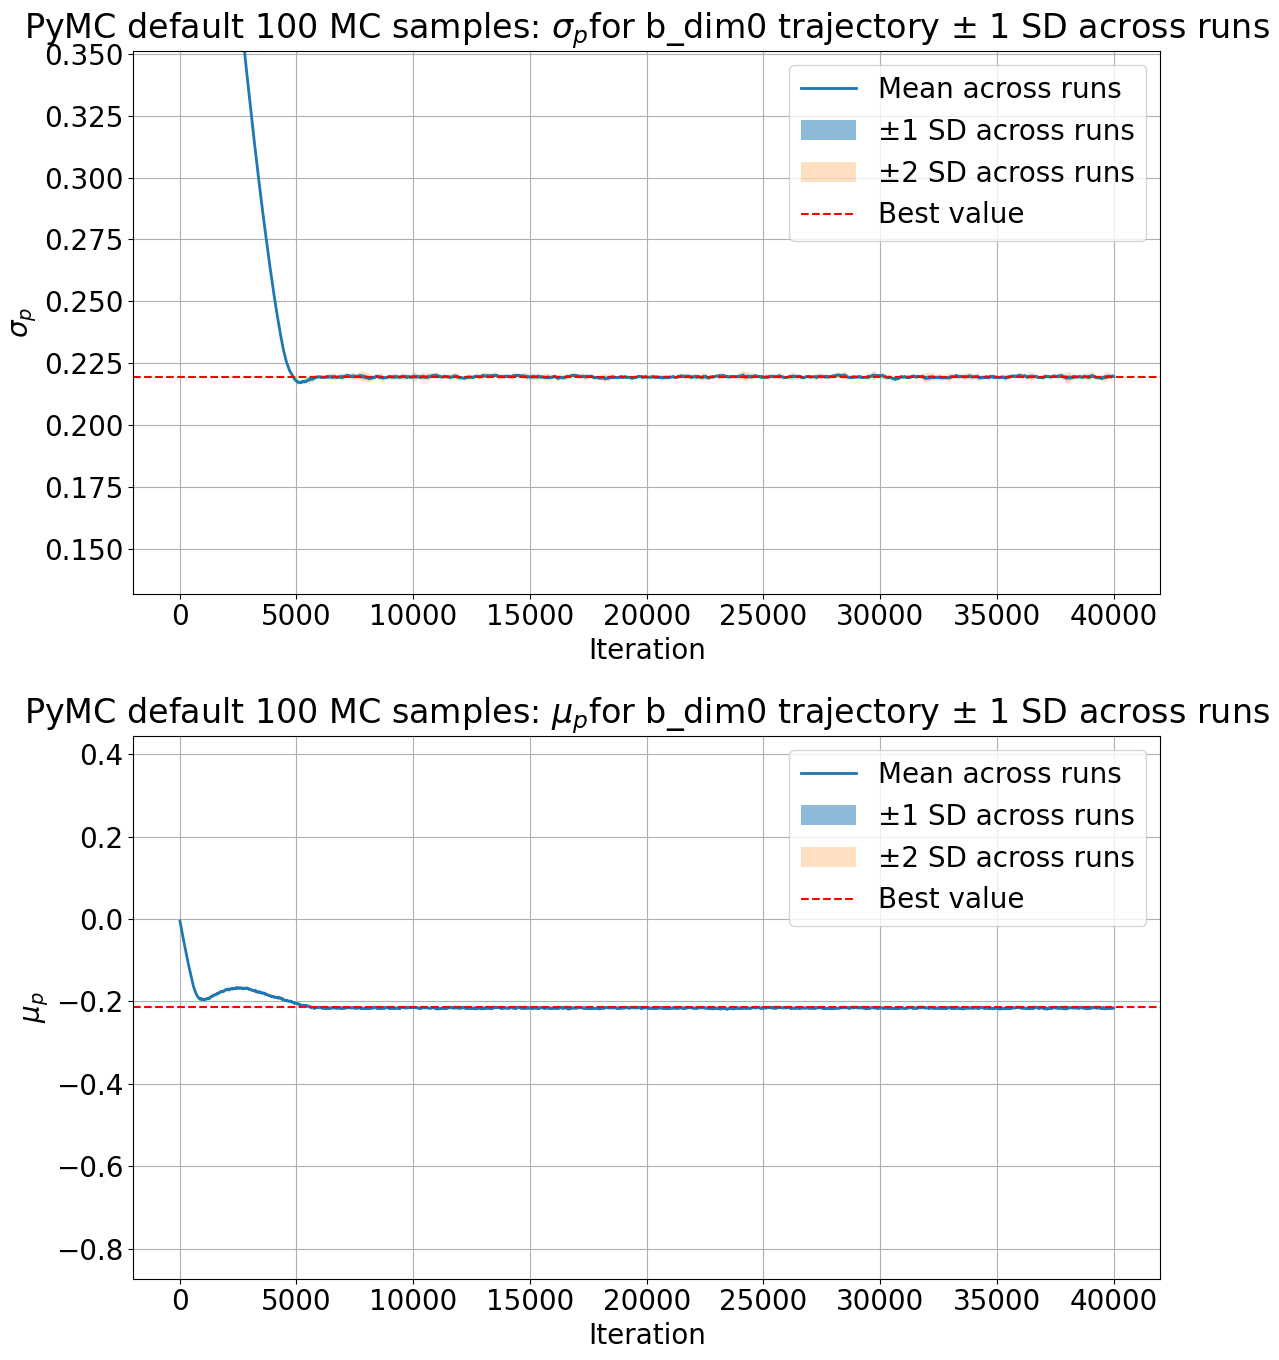

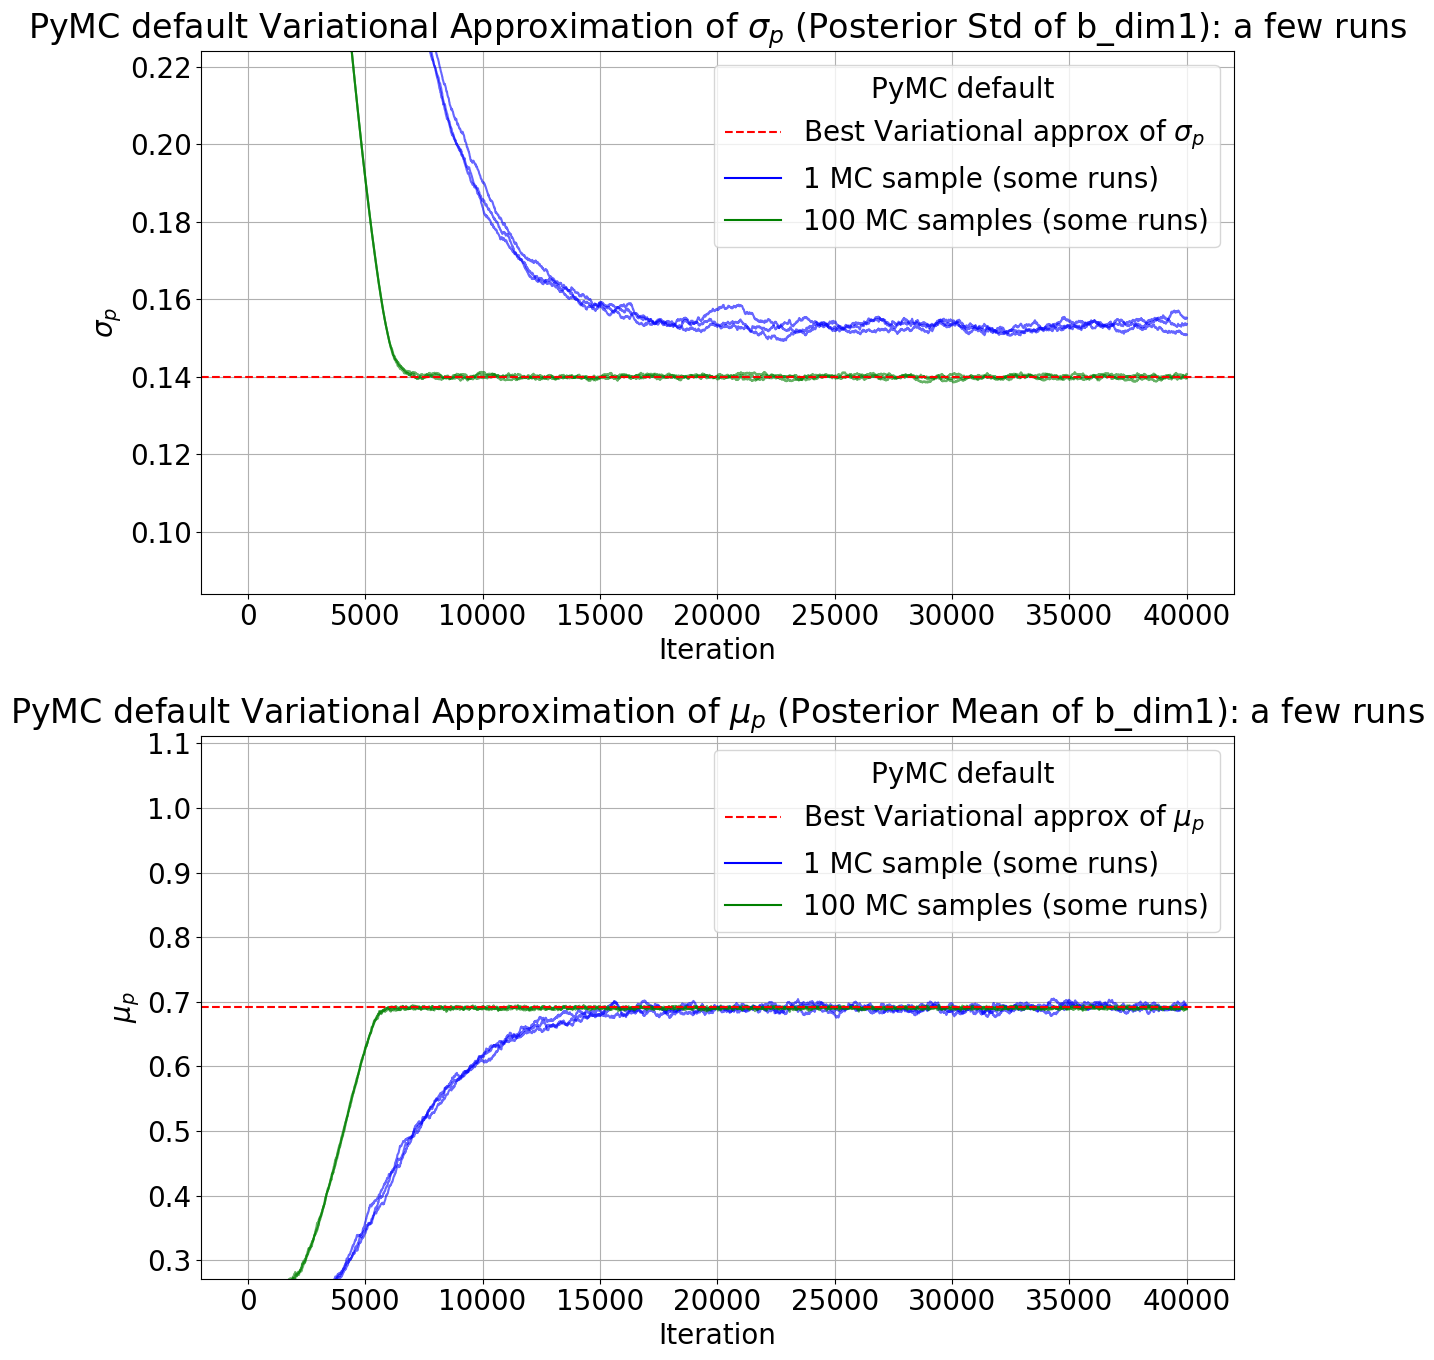

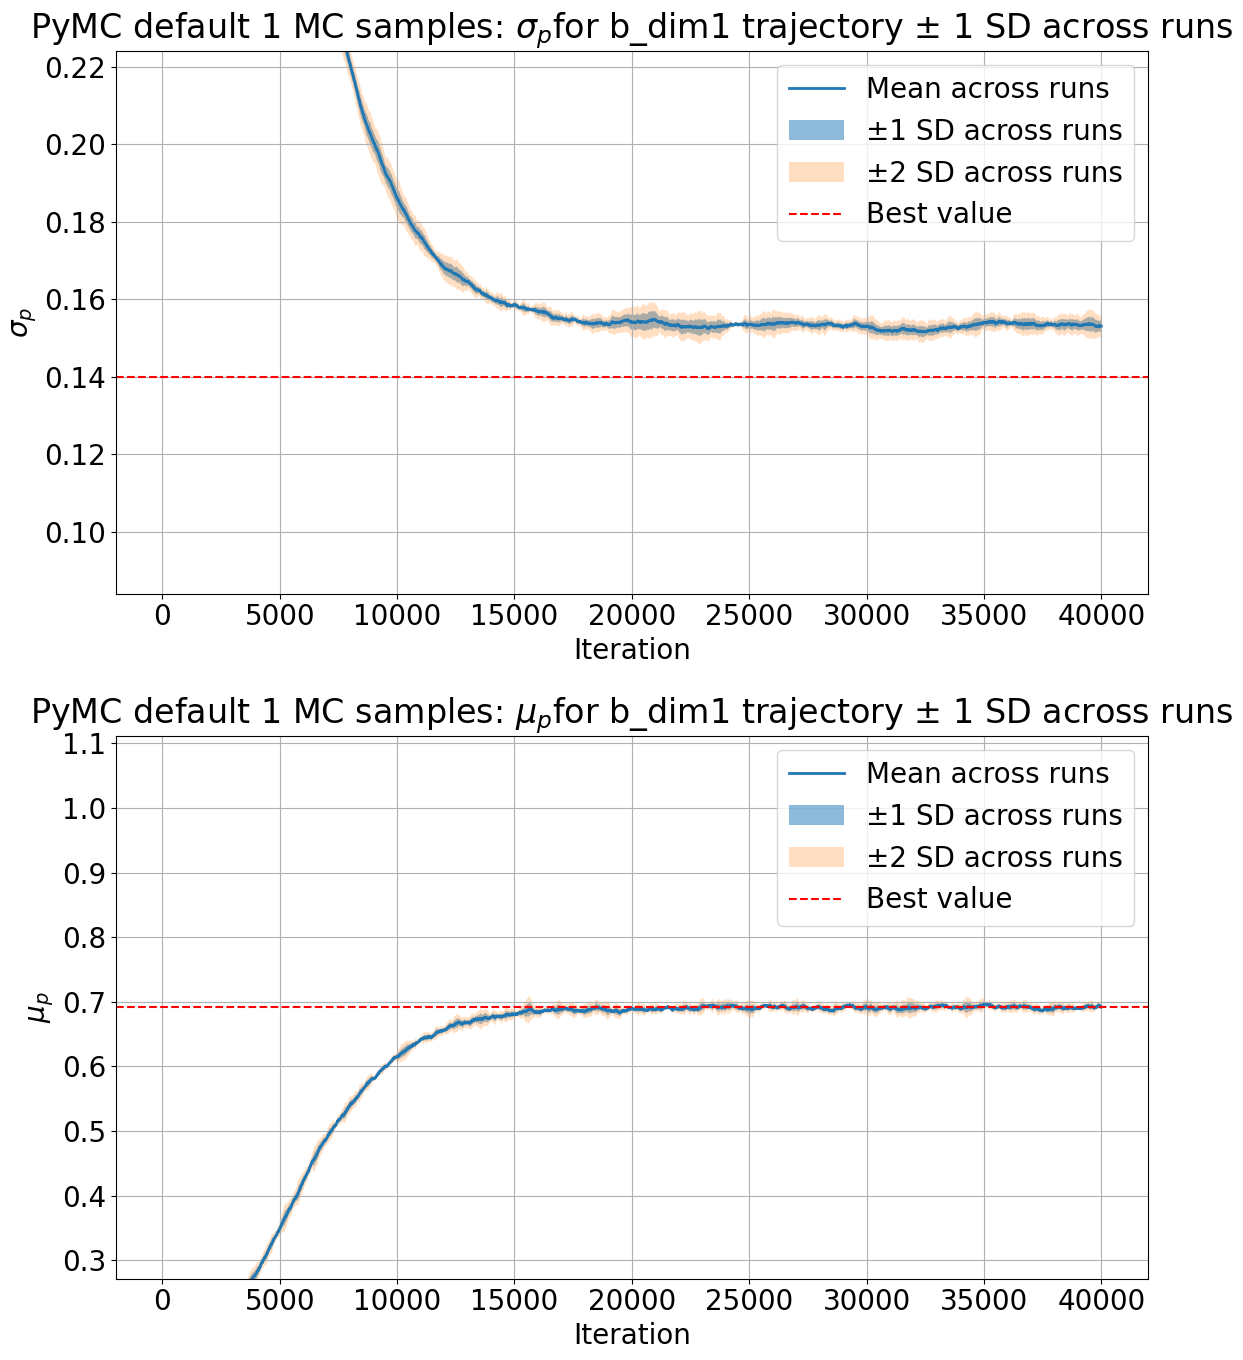

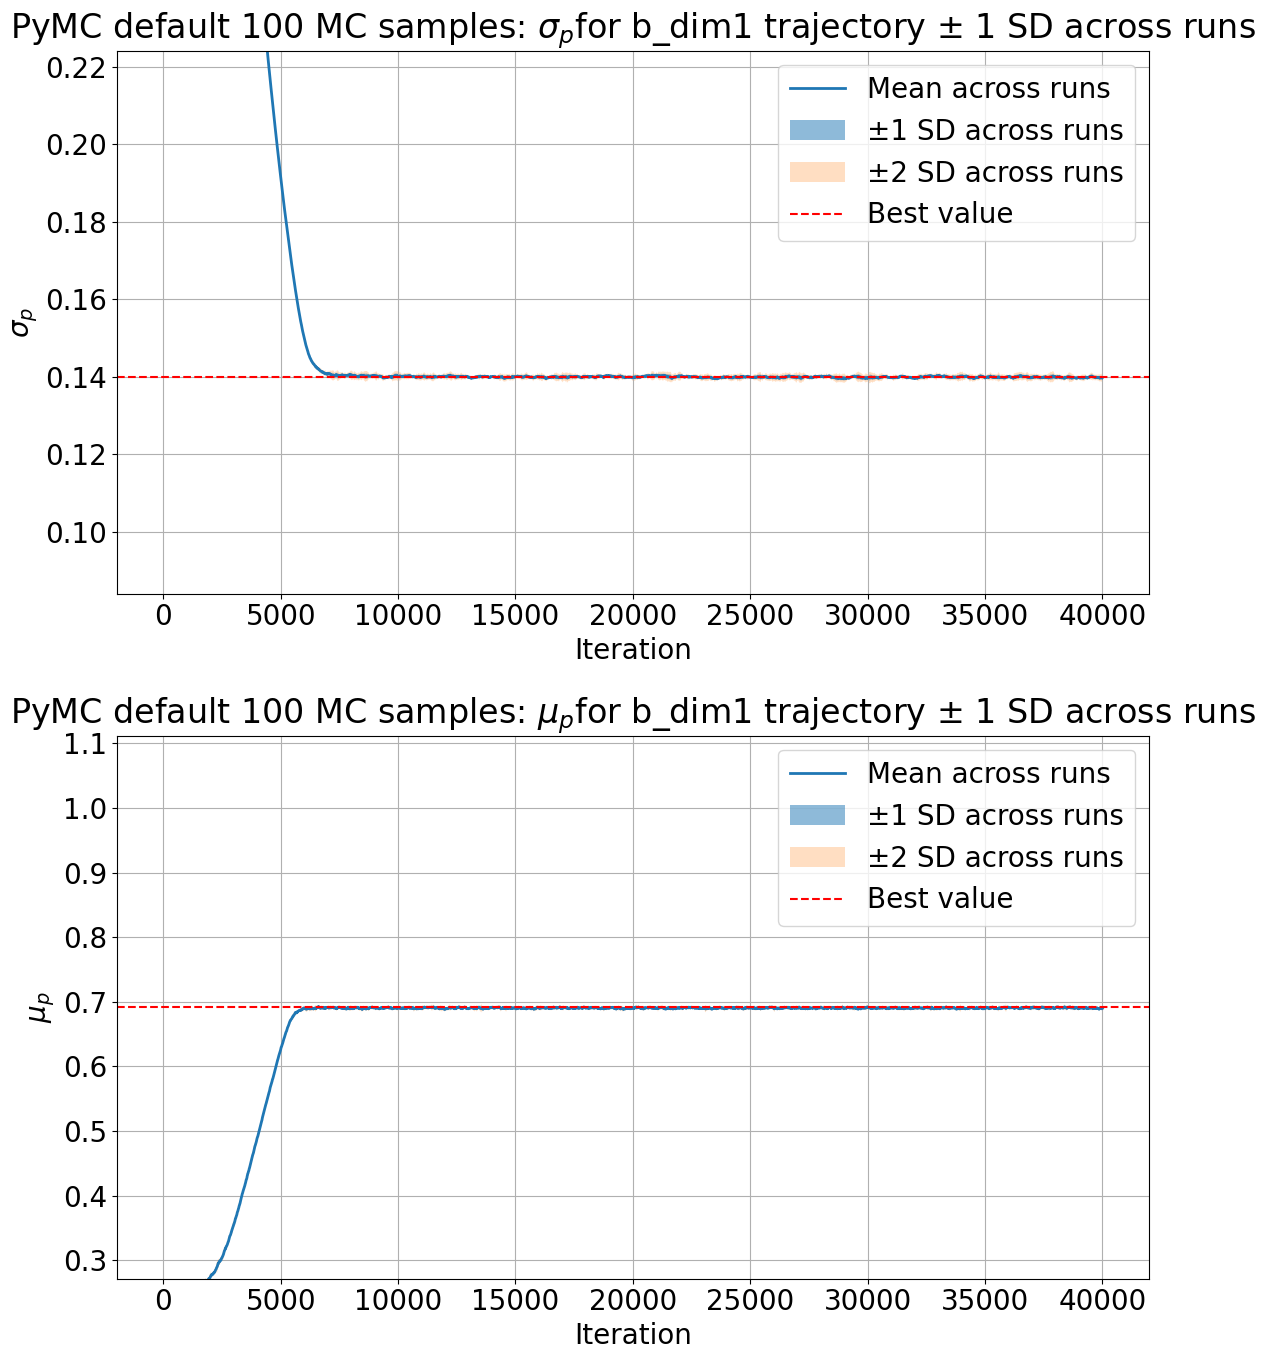

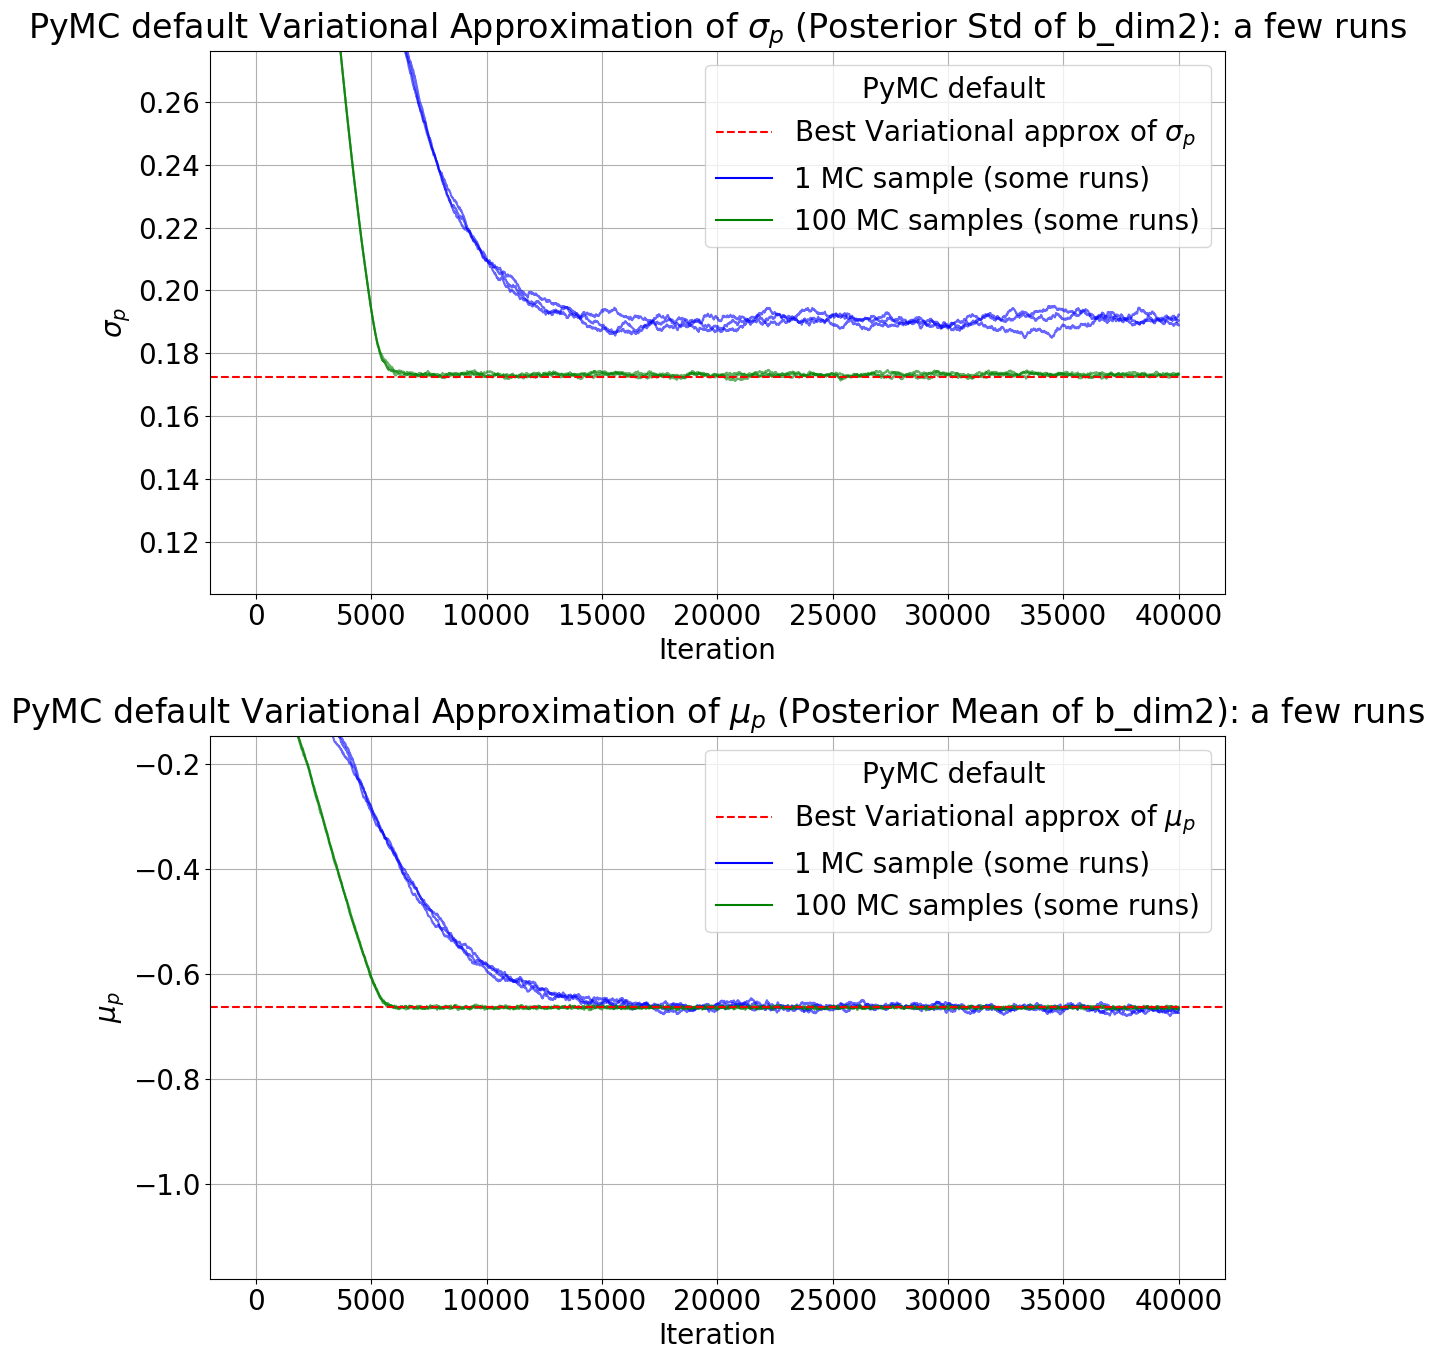

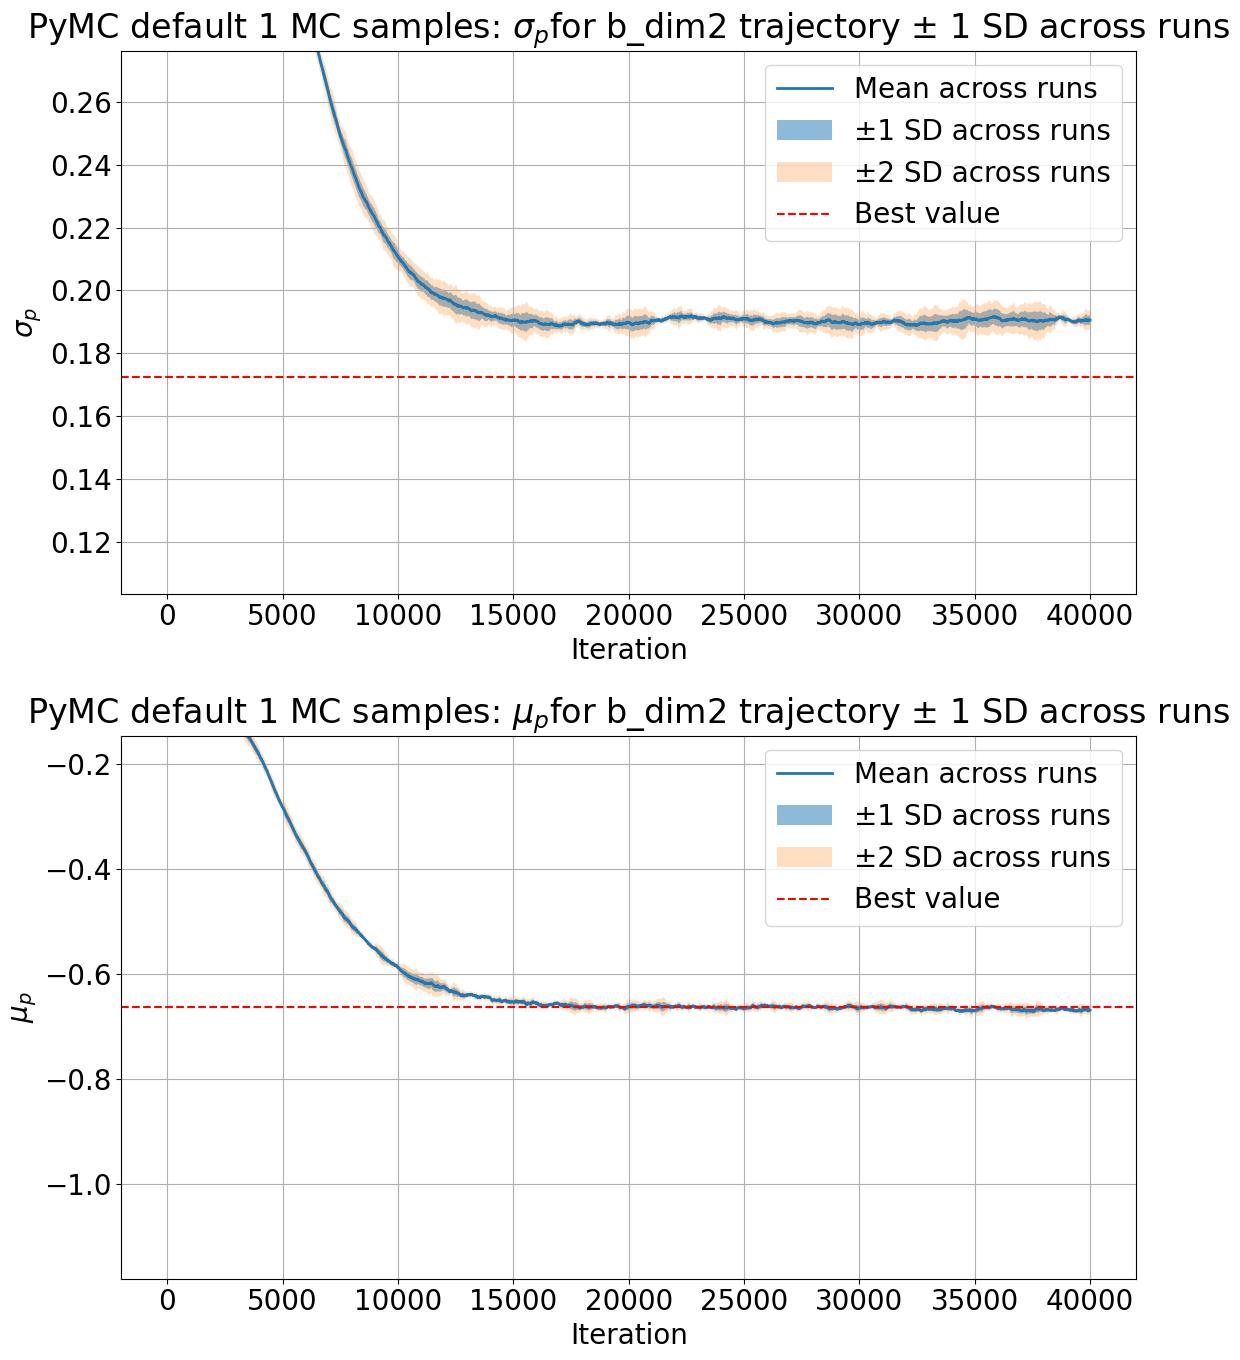

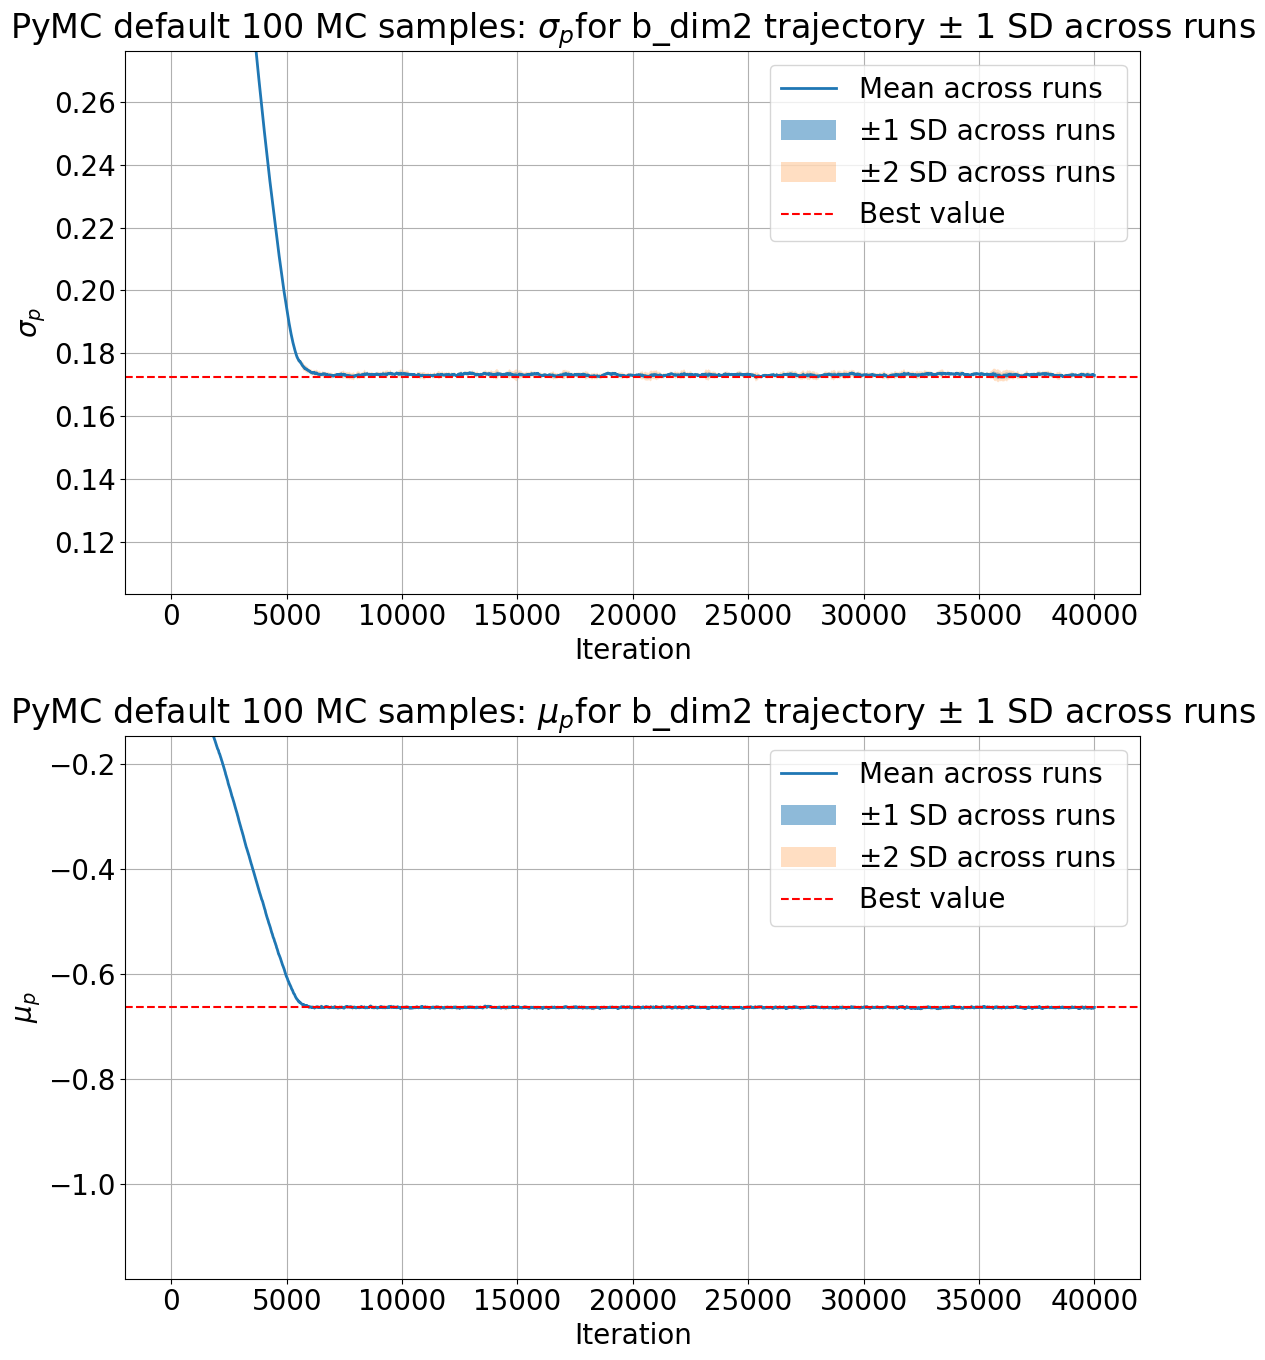

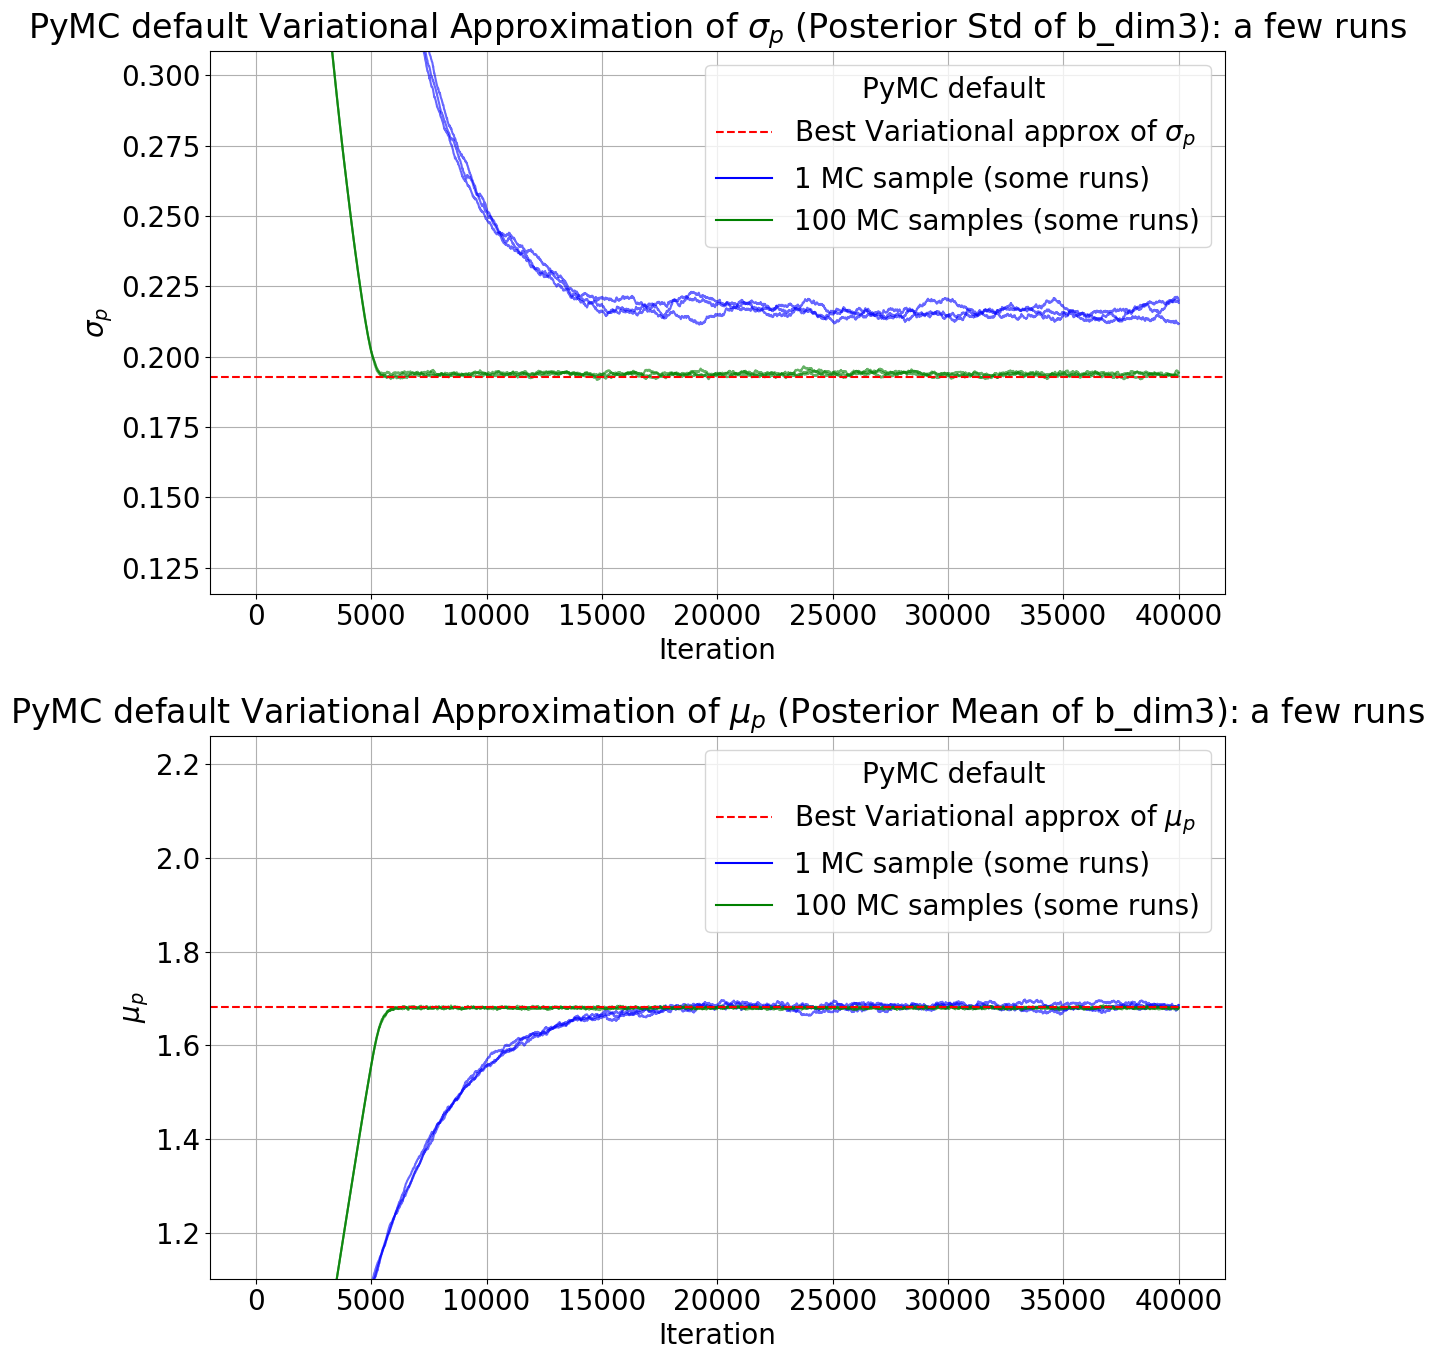

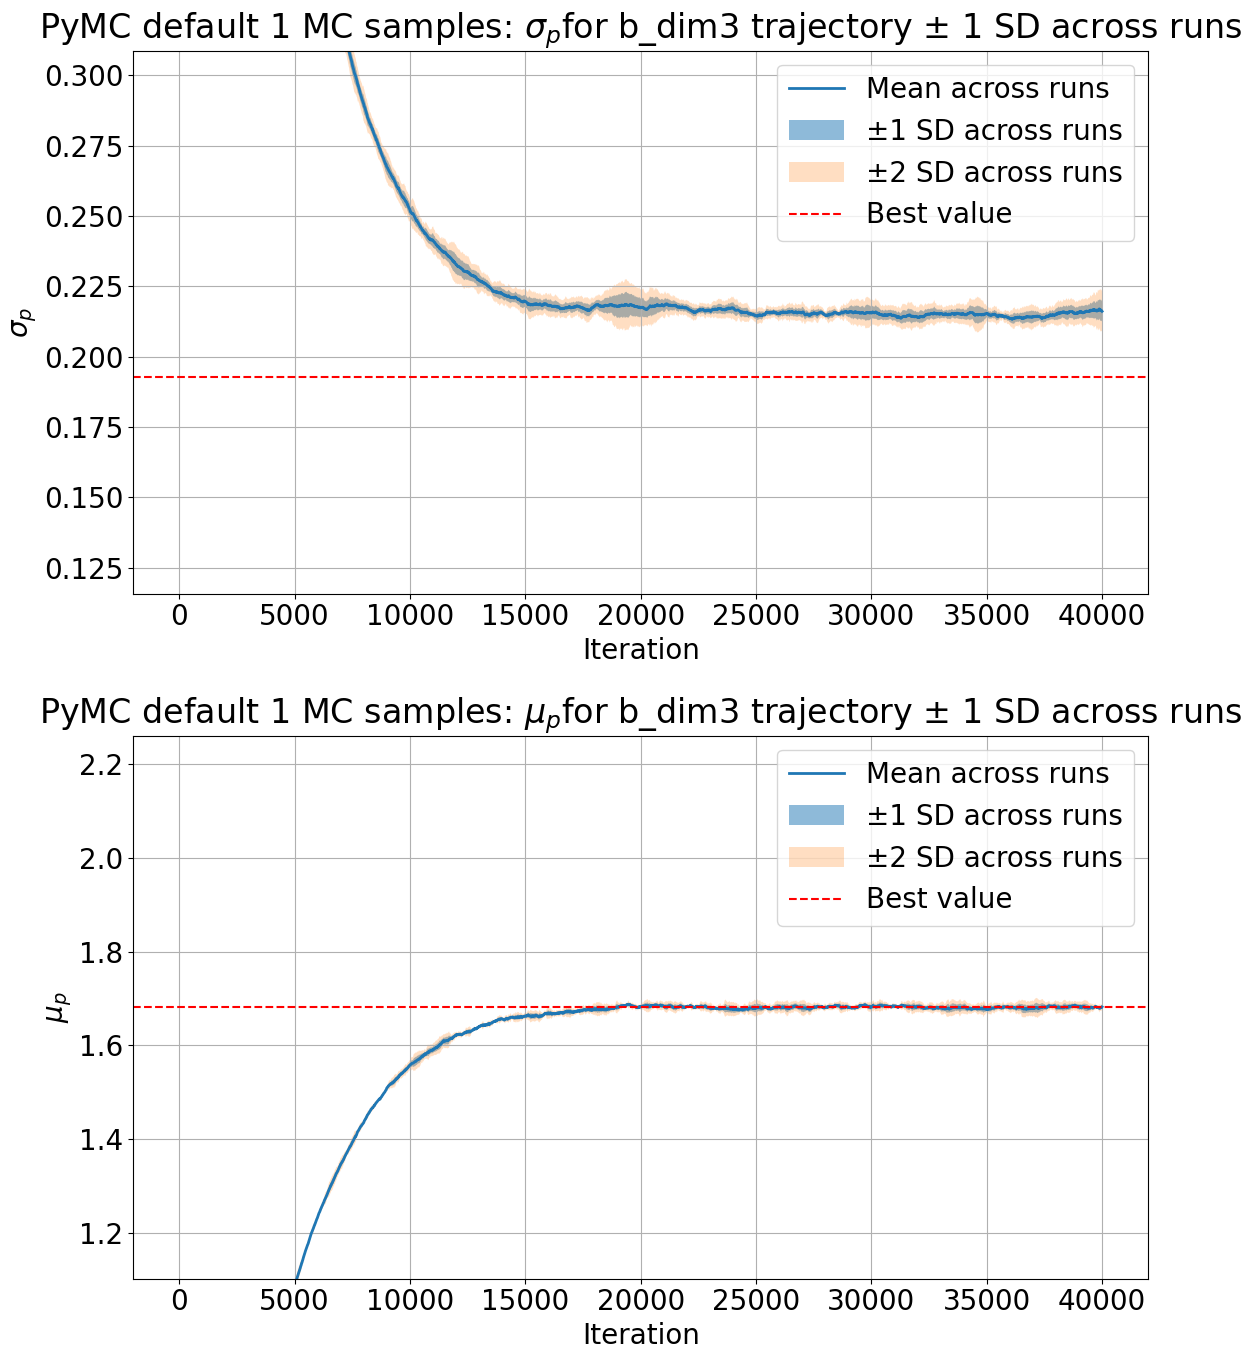

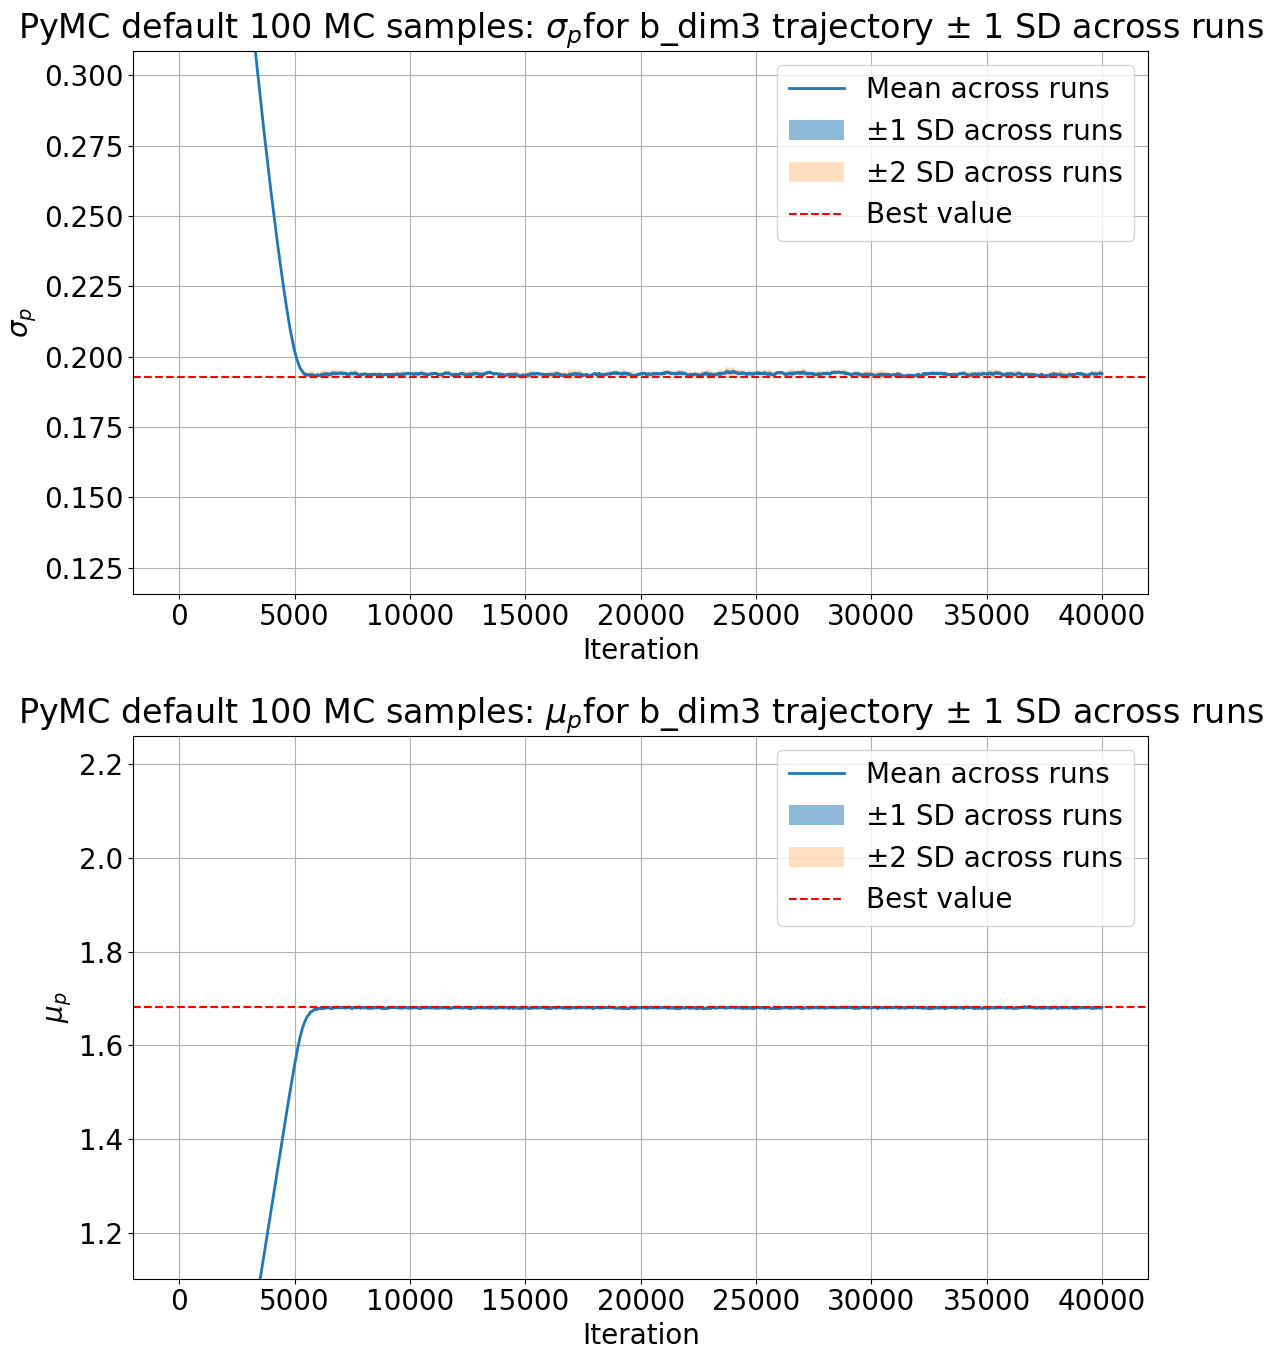

In [12]:

plot_some_dims_multid(
    single_means, single_stds, multi_means, multi_stds,
    best_mean, best_std,
    param_name="b",
    dim=dim,
    which_dims=list(range(dim)),
    k=min(3, n_restarts),
    label_prefix="PyMC default ",
    iteration_stride=track_every
)

# Adam results


In [6]:
from modulars.utils import load_from_csv
adam_processed_results = load_from_csv(results_dir / "pymc_adam_processed_restarts.csv")
adam_single_means, adam_single_stds, adam_multi_means, adam_multi_stds = adam_processed_results[0]

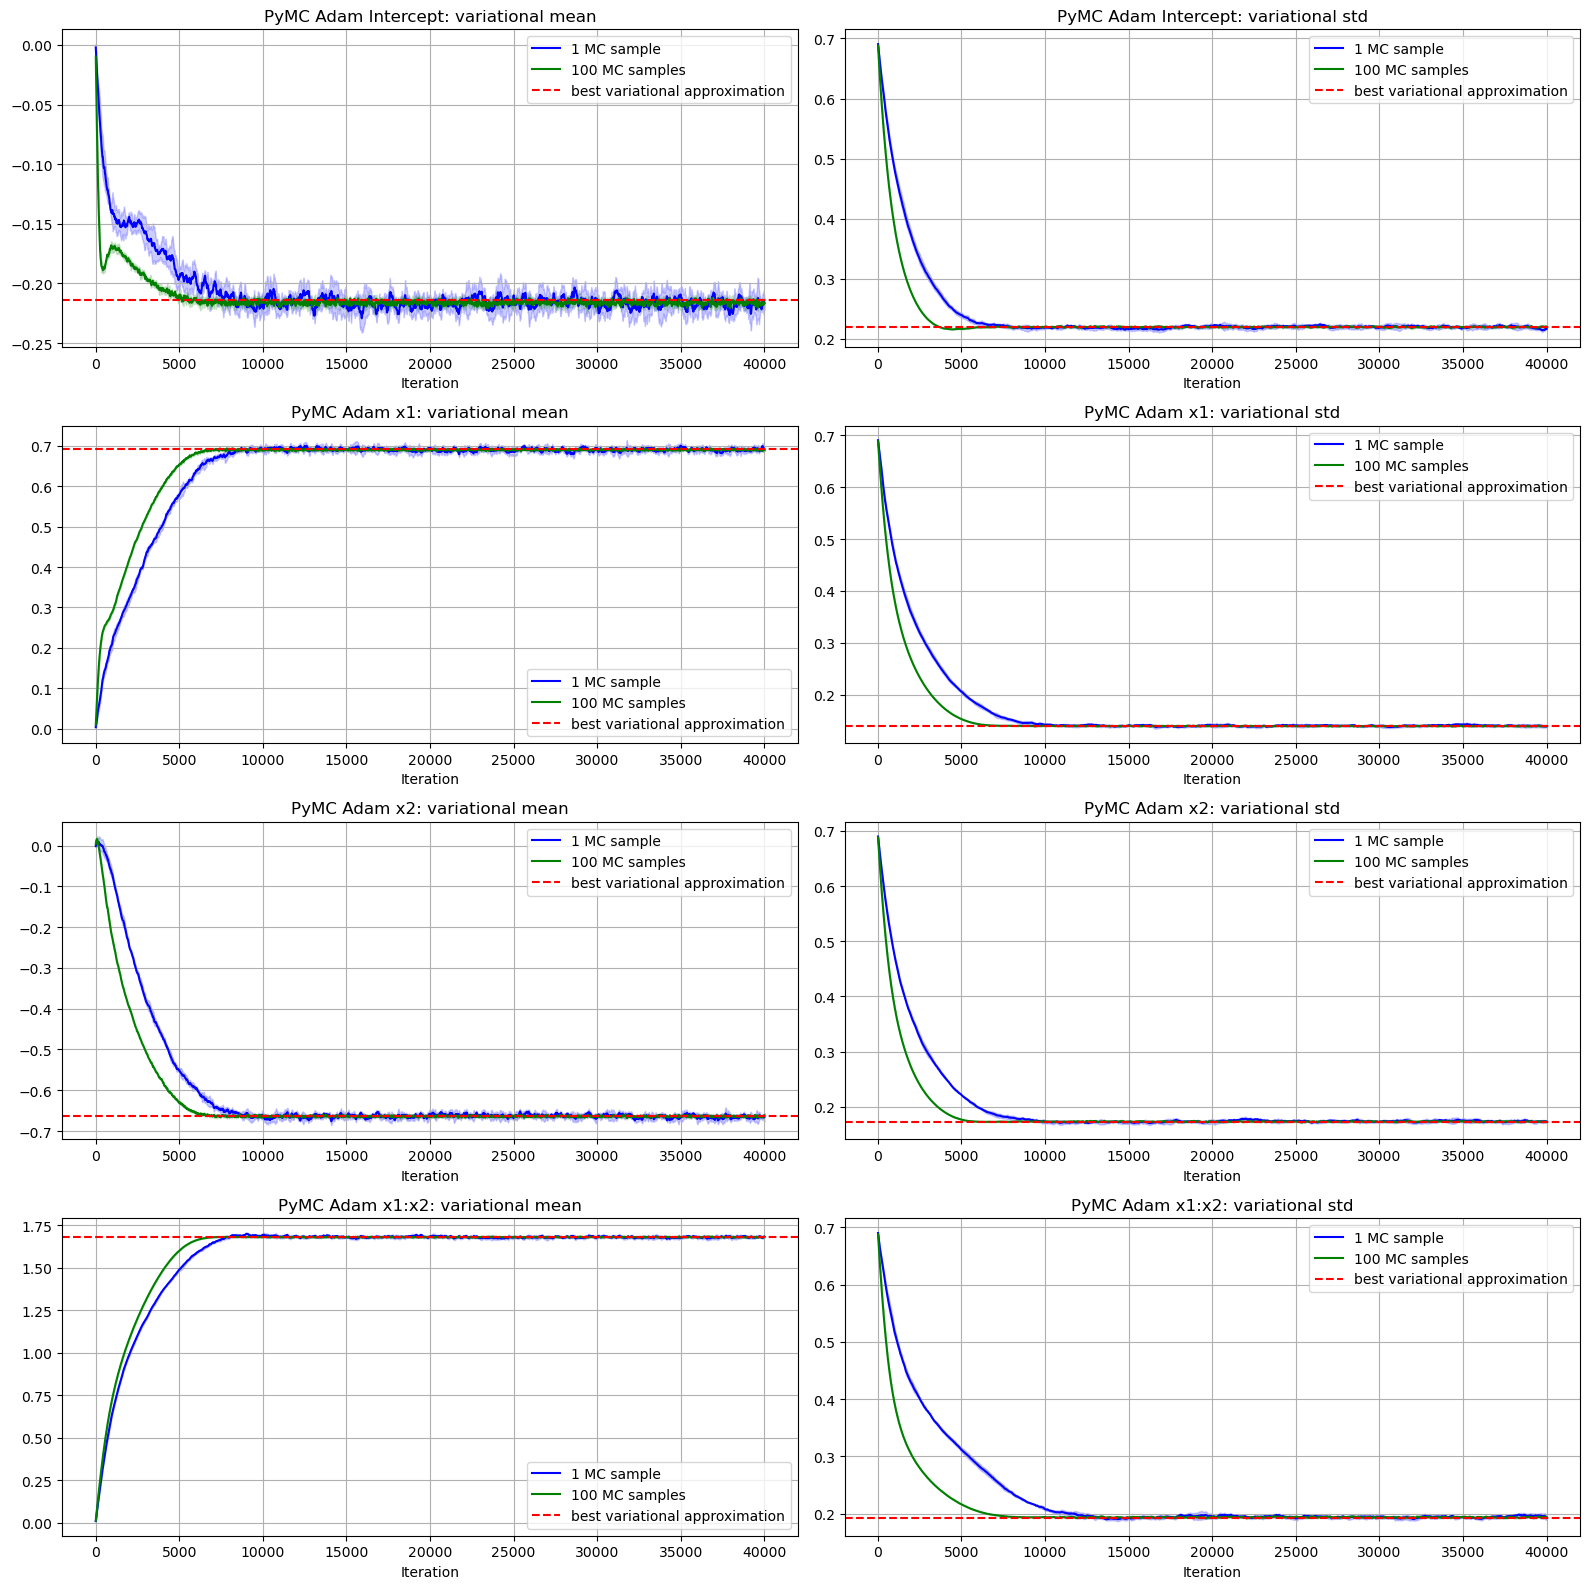

In [7]:
plot_logistic_regression_selected_coeffs(
    adam_single_means, adam_single_stds, adam_multi_means, adam_multi_stds,
    labels=labels,
    title_prefix="PyMC Adam ",
    reference_means=reference_means,
    reference_stds=reference_stds,
    iteration_stride=track_every
)


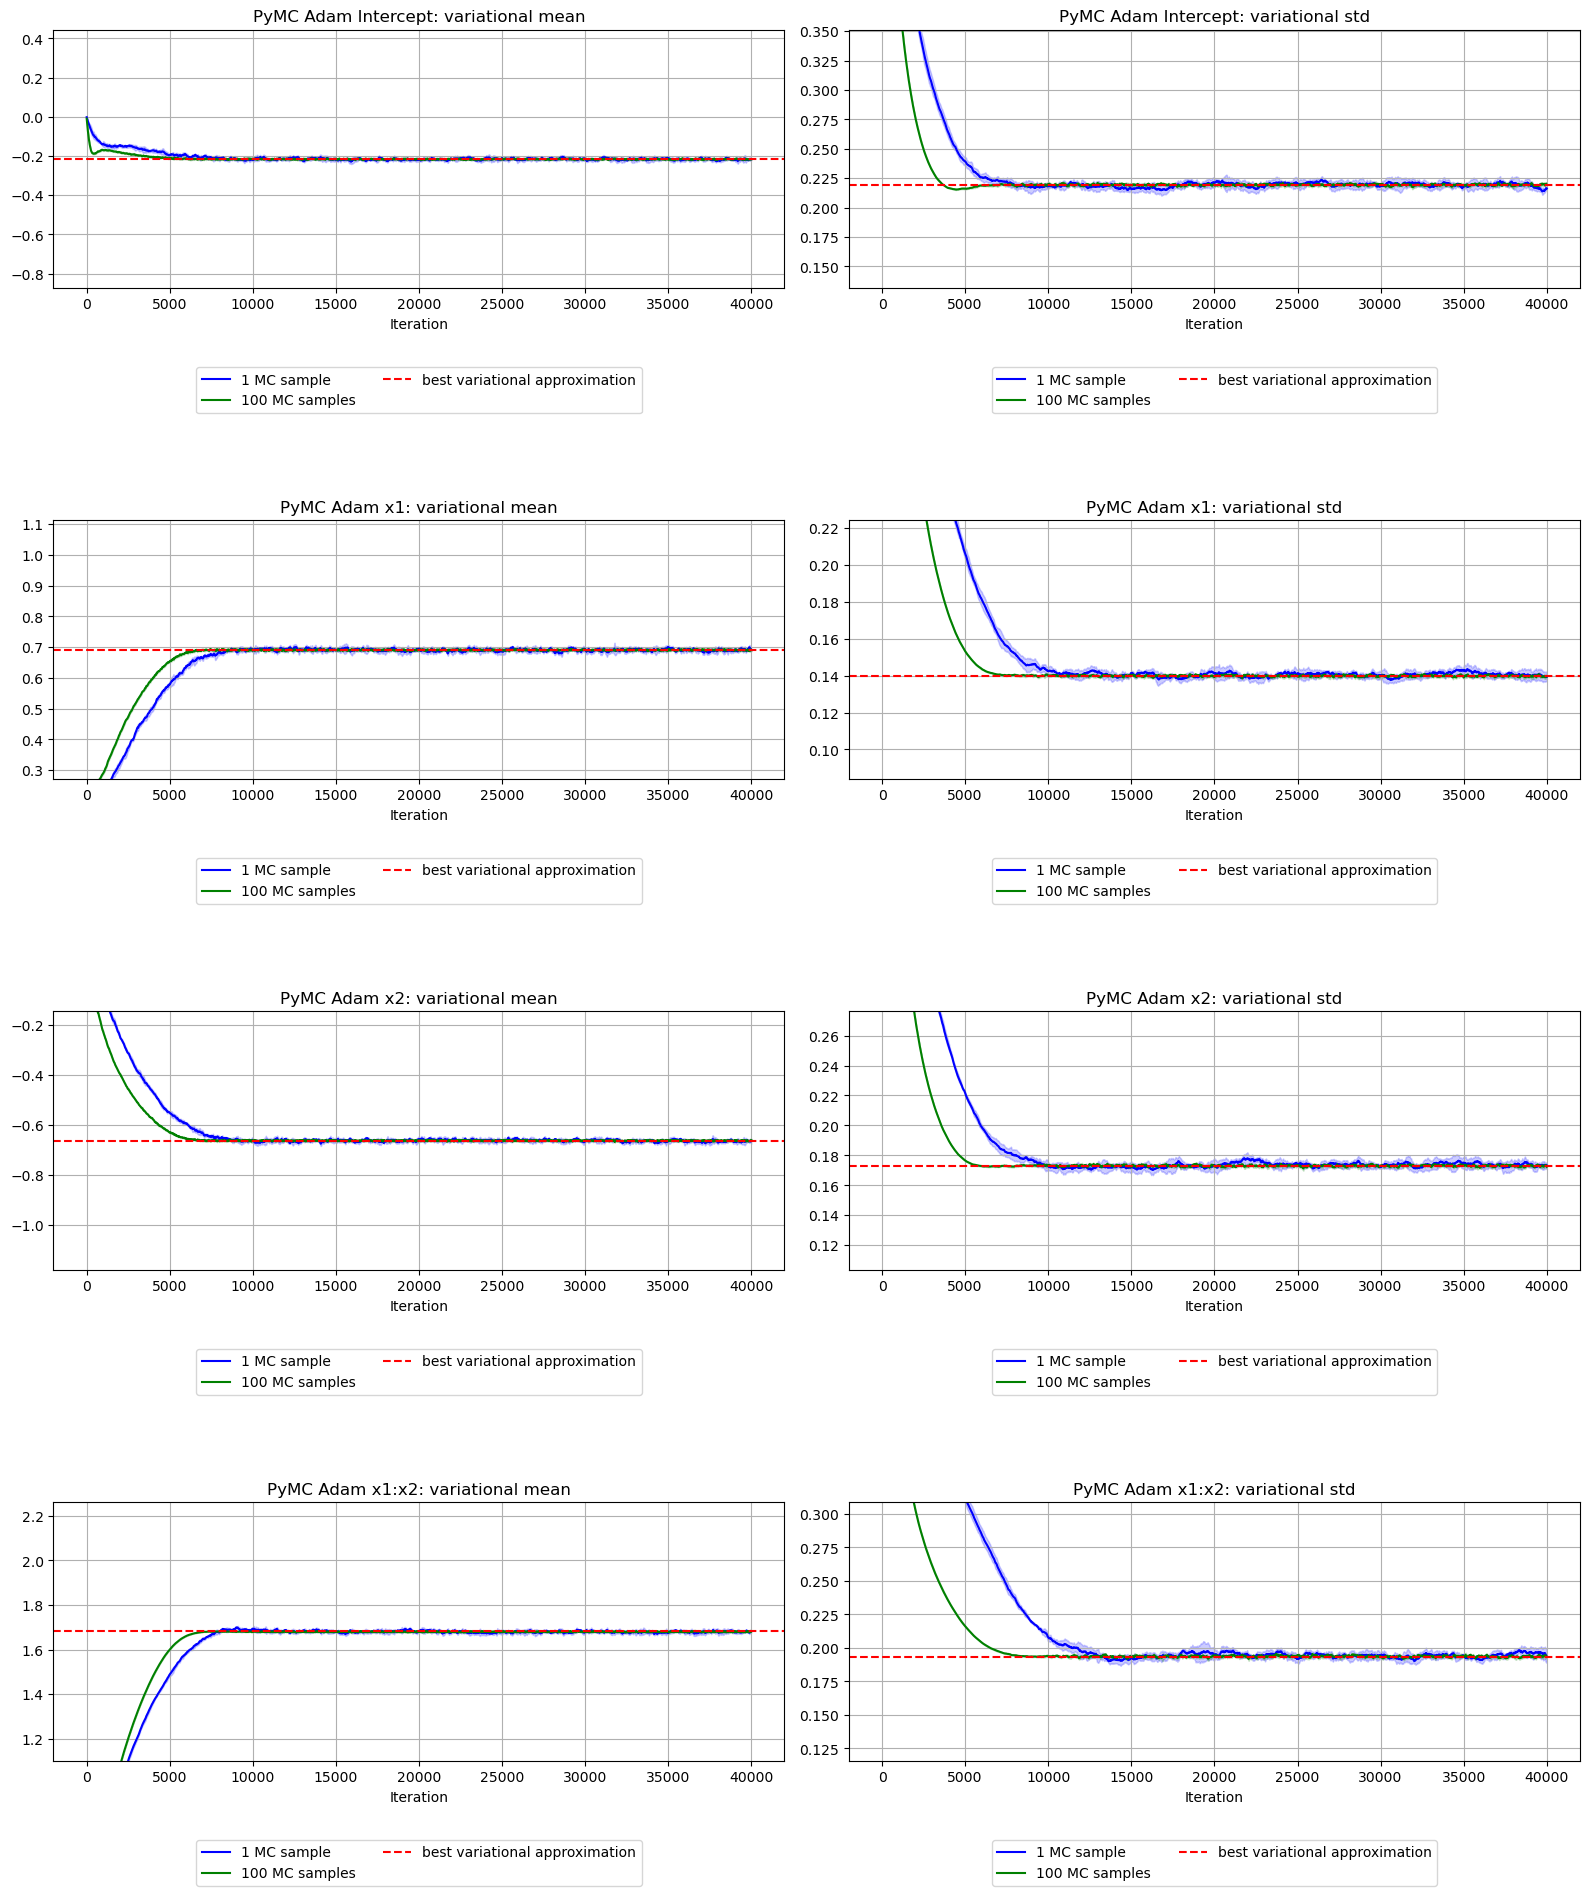

In [9]:
import modulars.logistic_regression
modulars.logistic_regression.plot_logistic_regression_selected_coeffs_zoomed(
    adam_single_means, adam_single_stds, adam_multi_means, adam_multi_stds,
    labels=labels,
    title_prefix="PyMC Adam ",
    reference_means=reference_means,
    reference_stds=reference_stds,
    iteration_stride=track_every
)

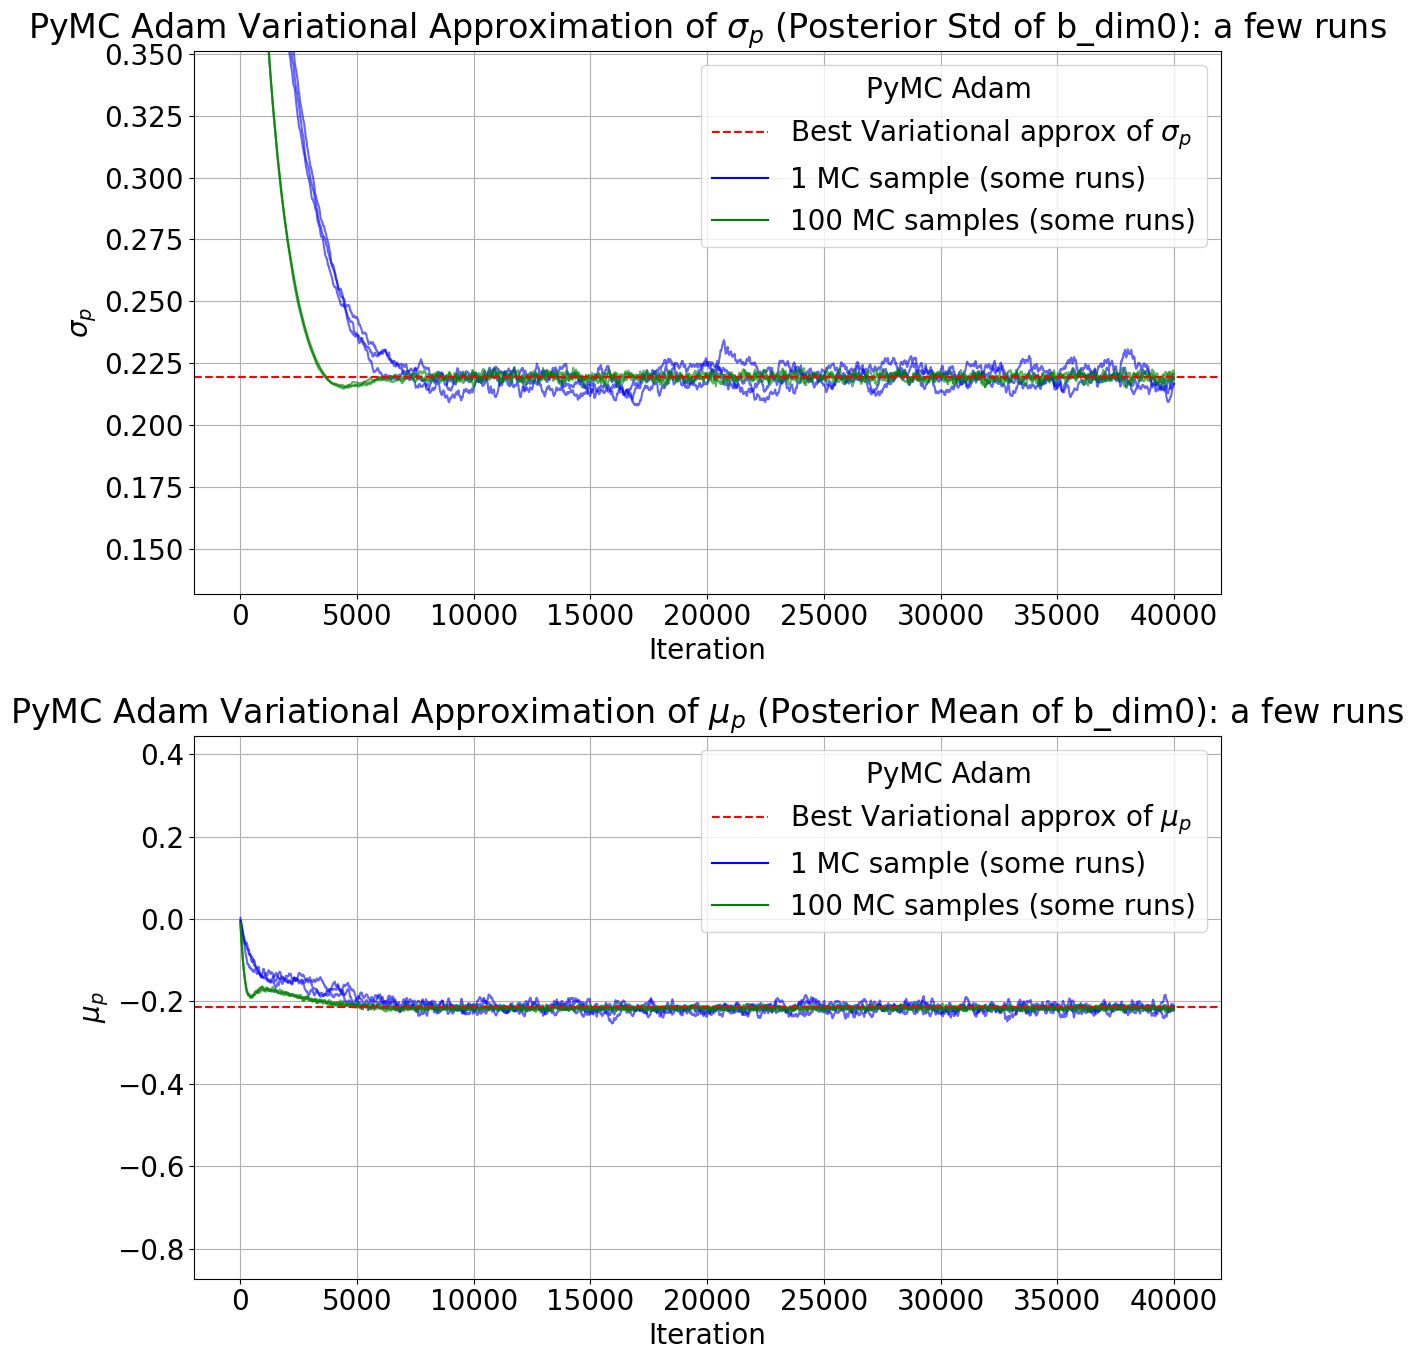

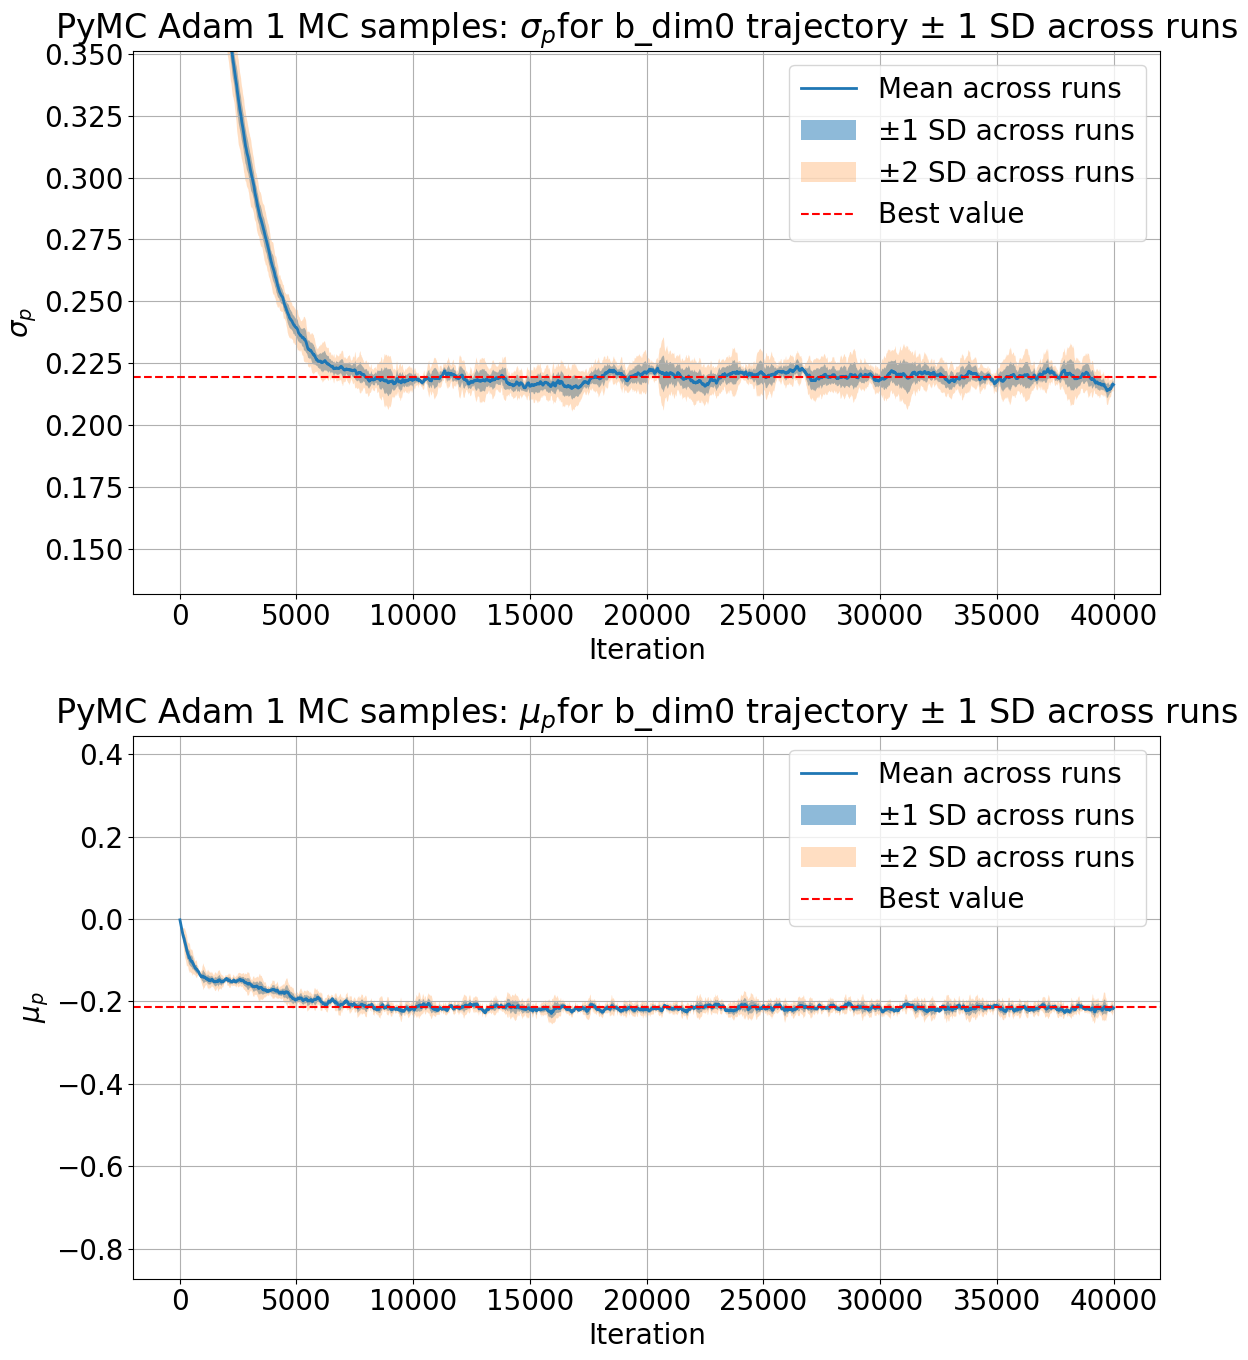

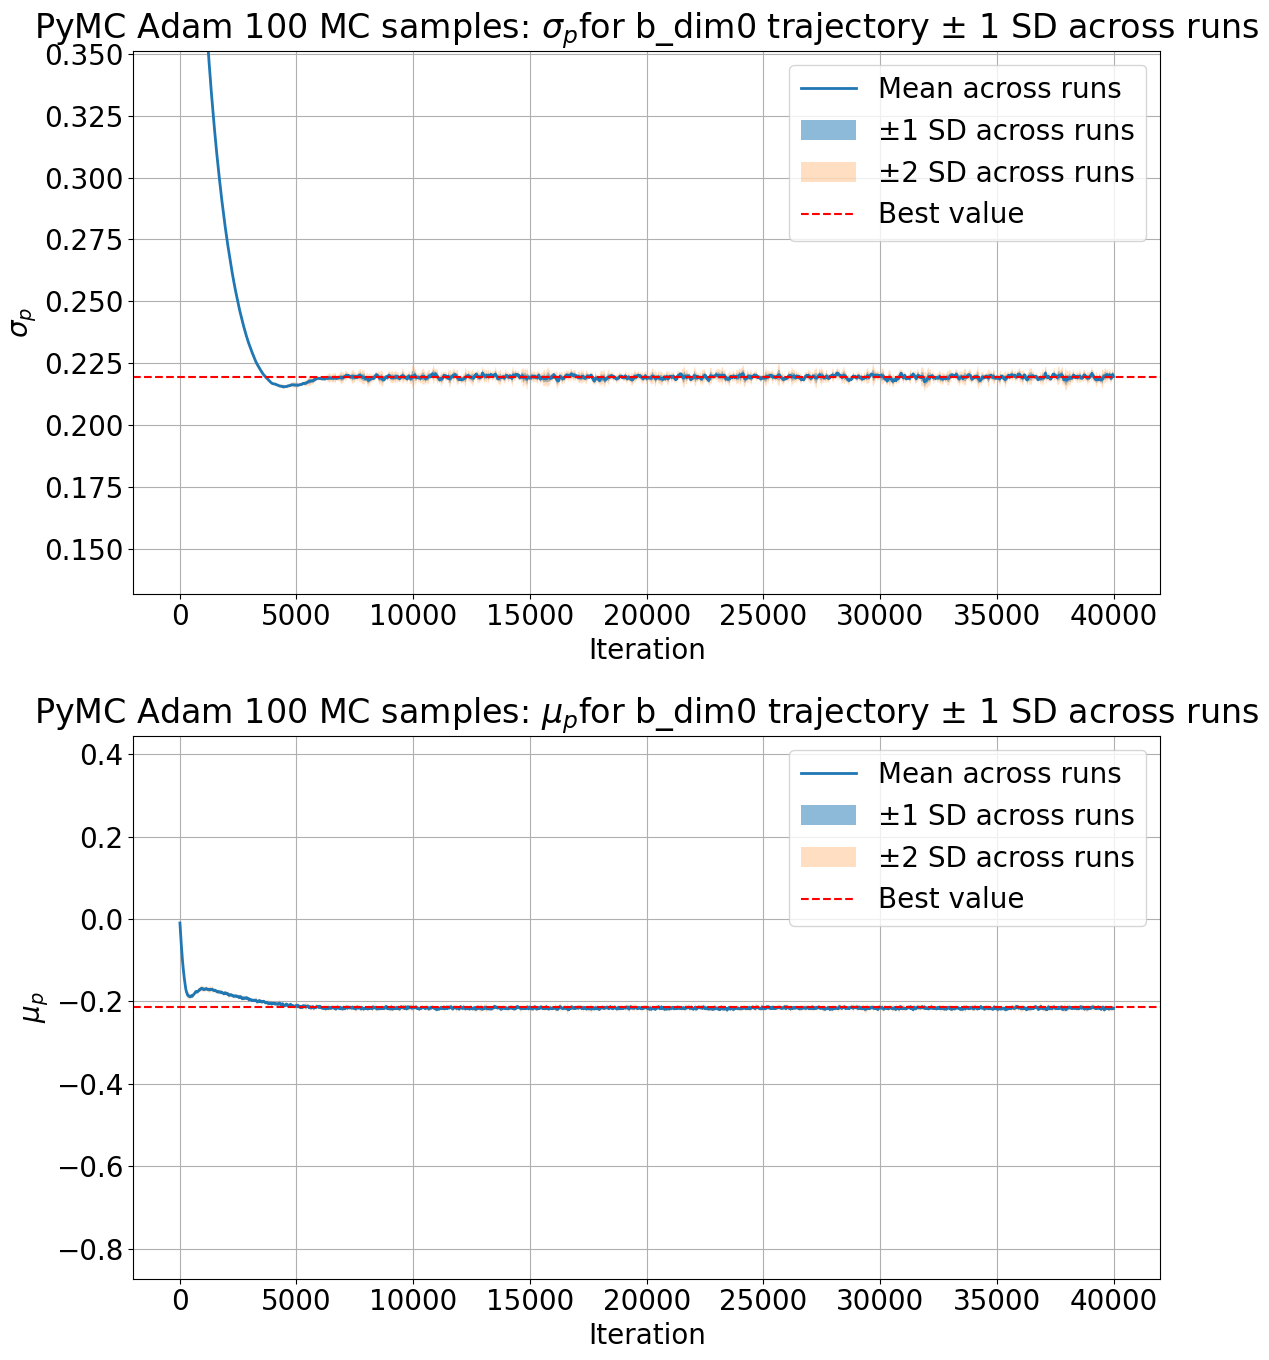

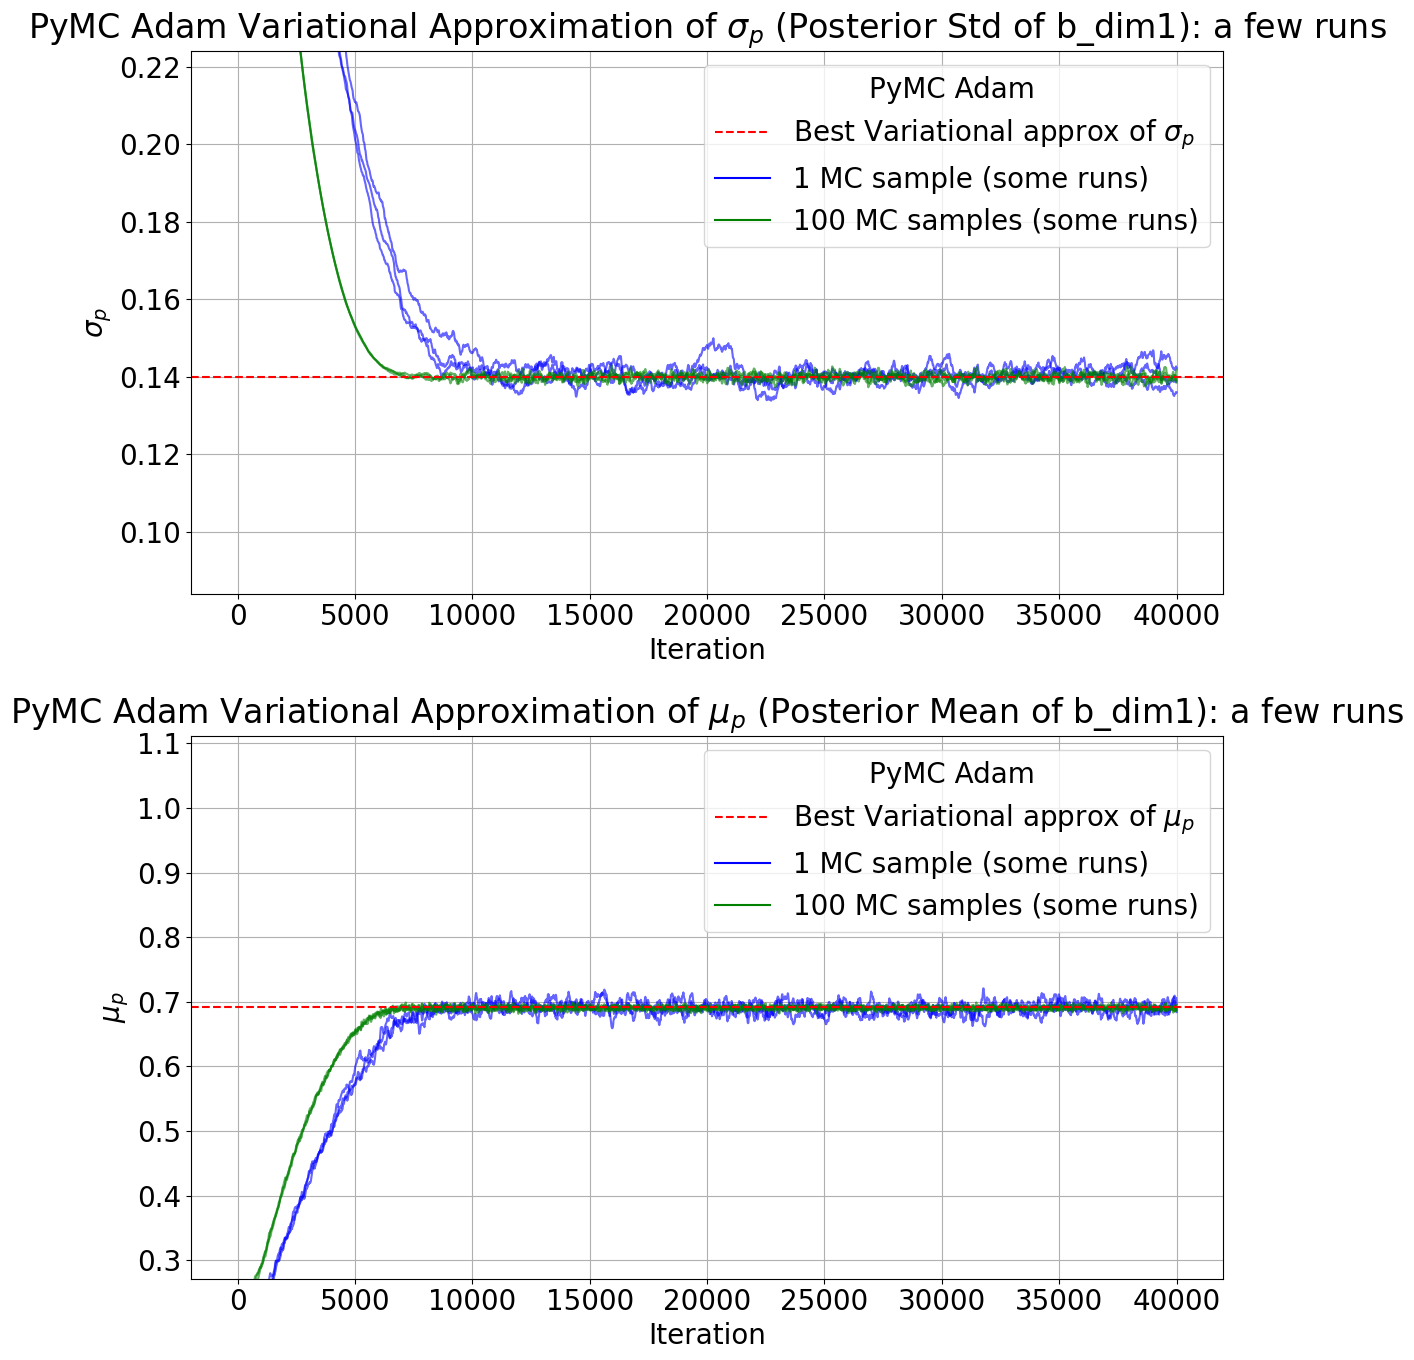

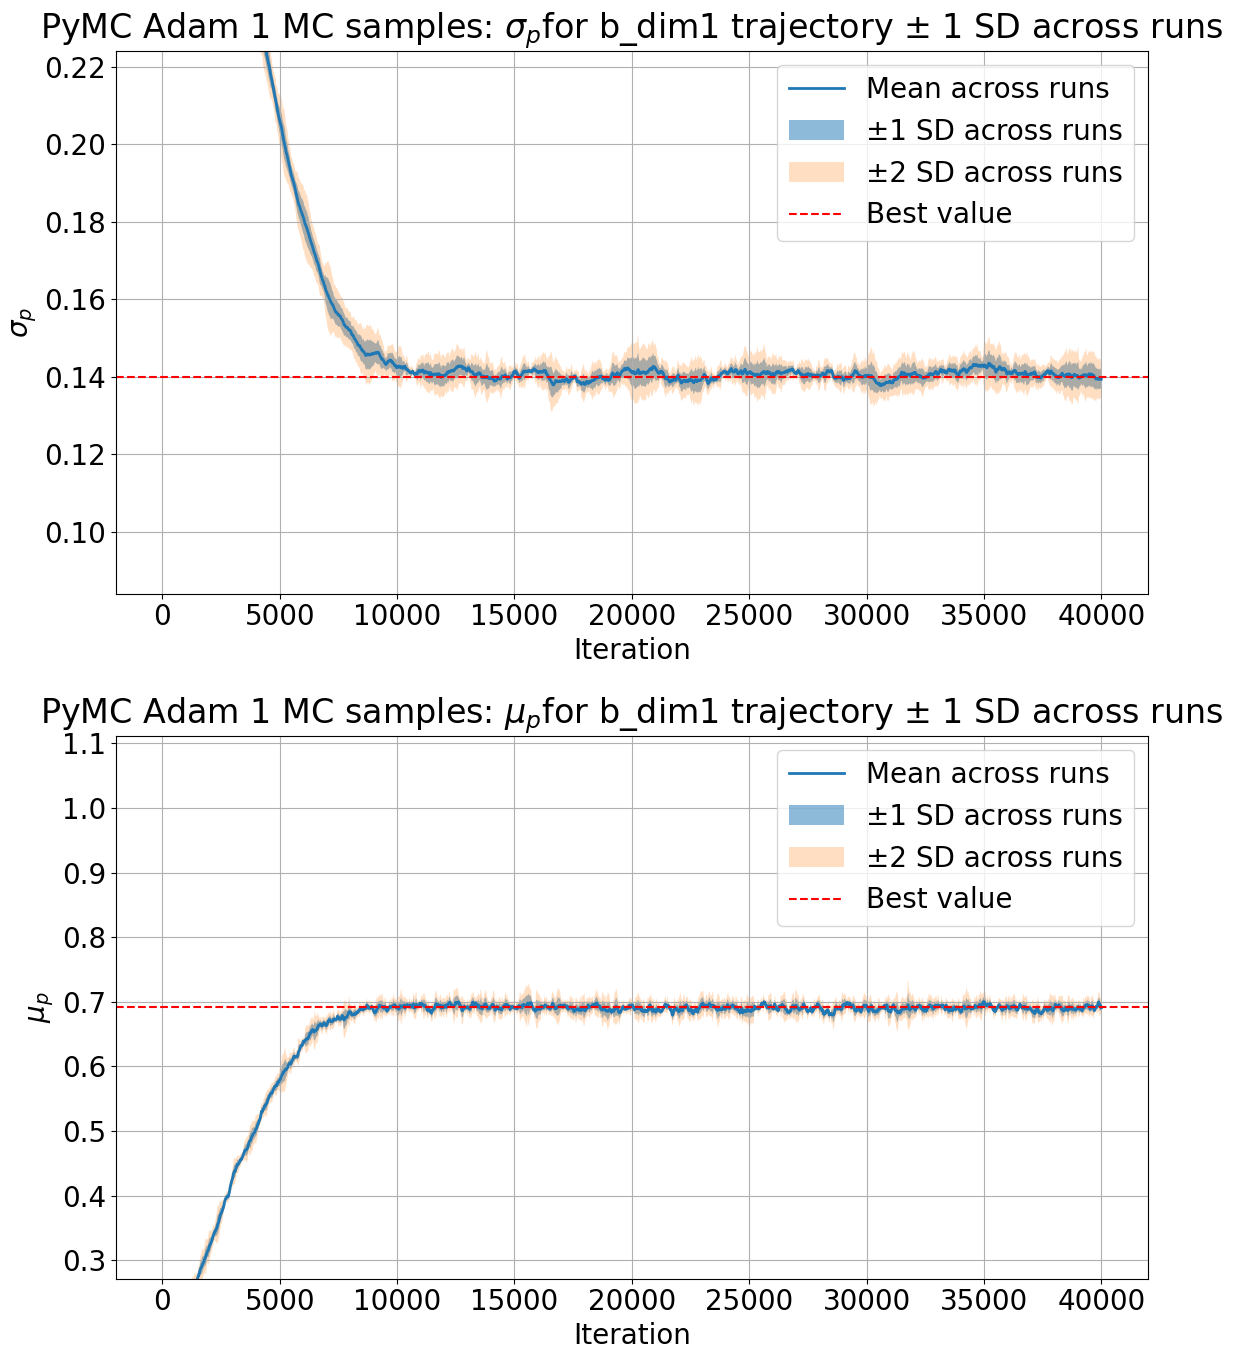

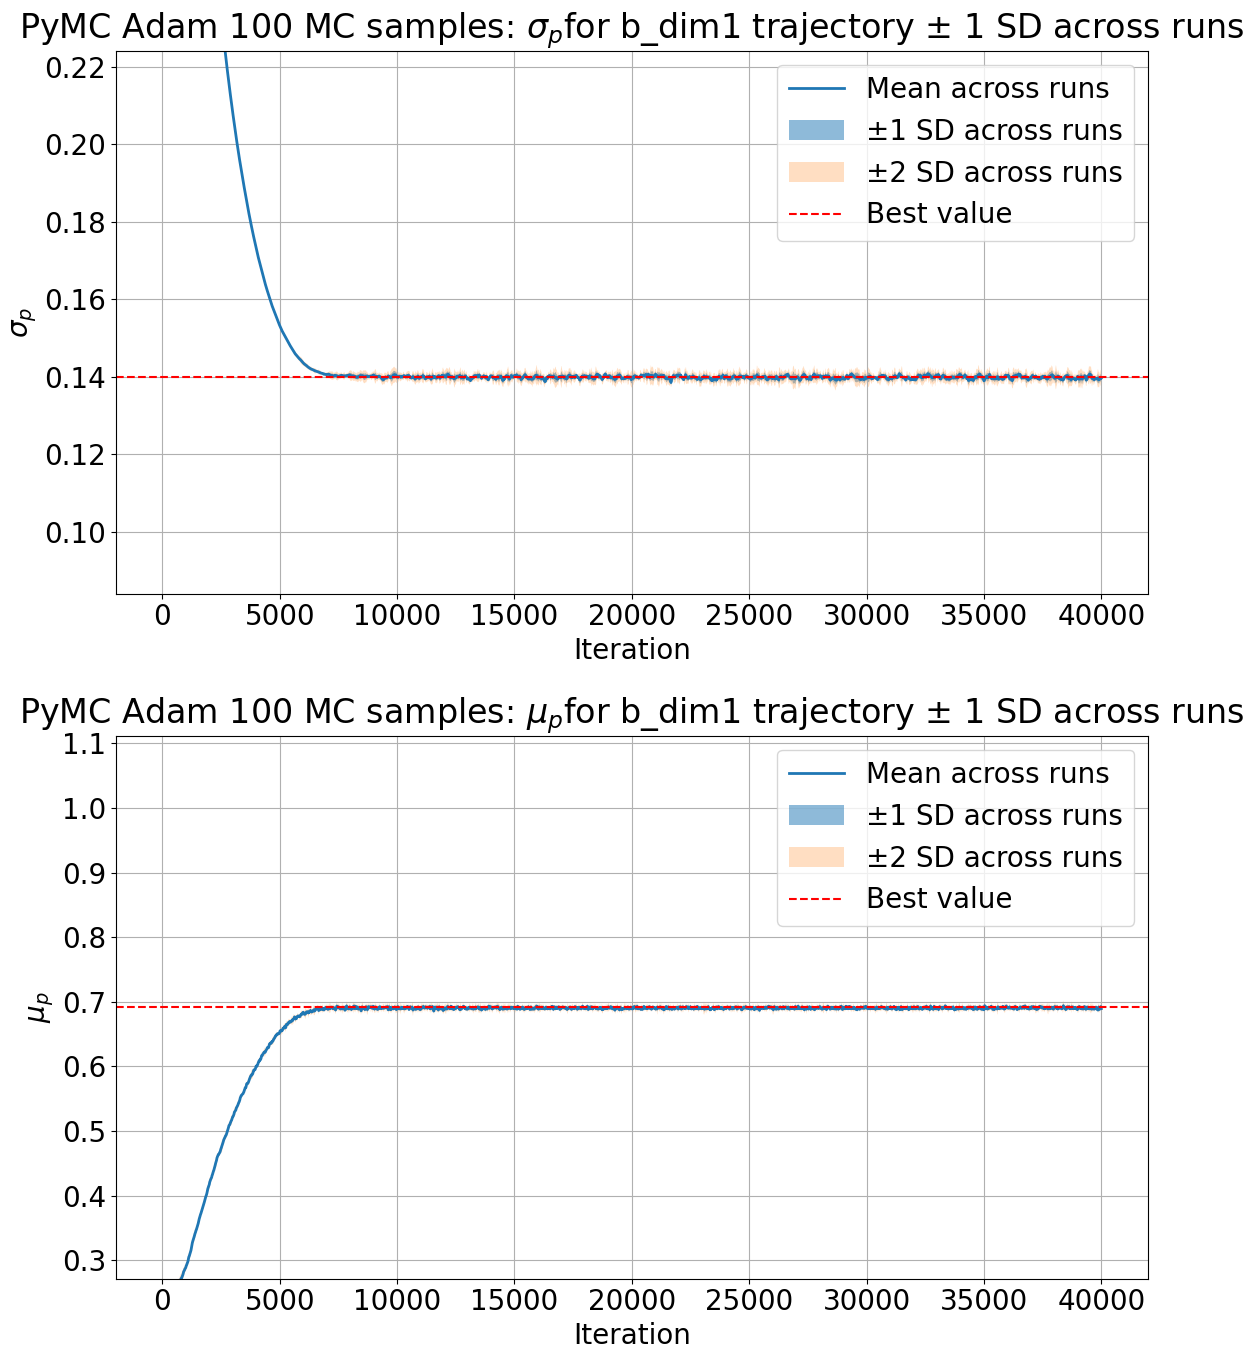

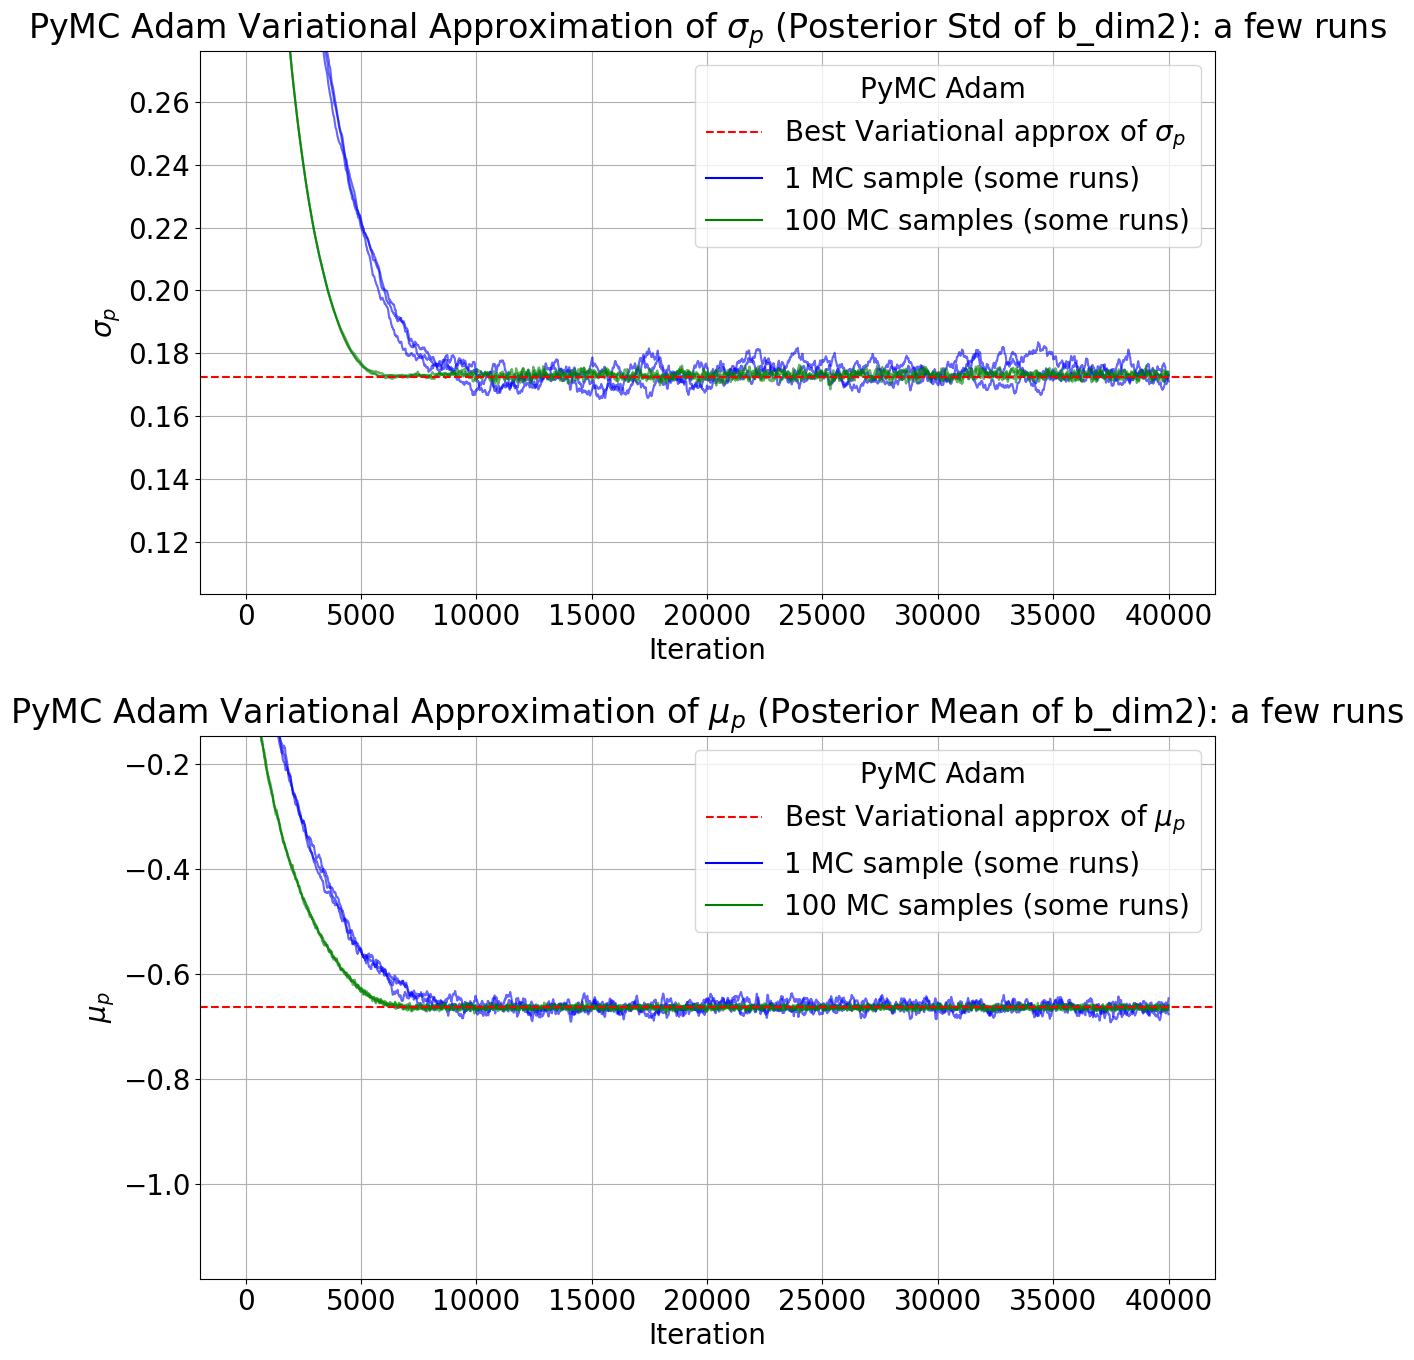

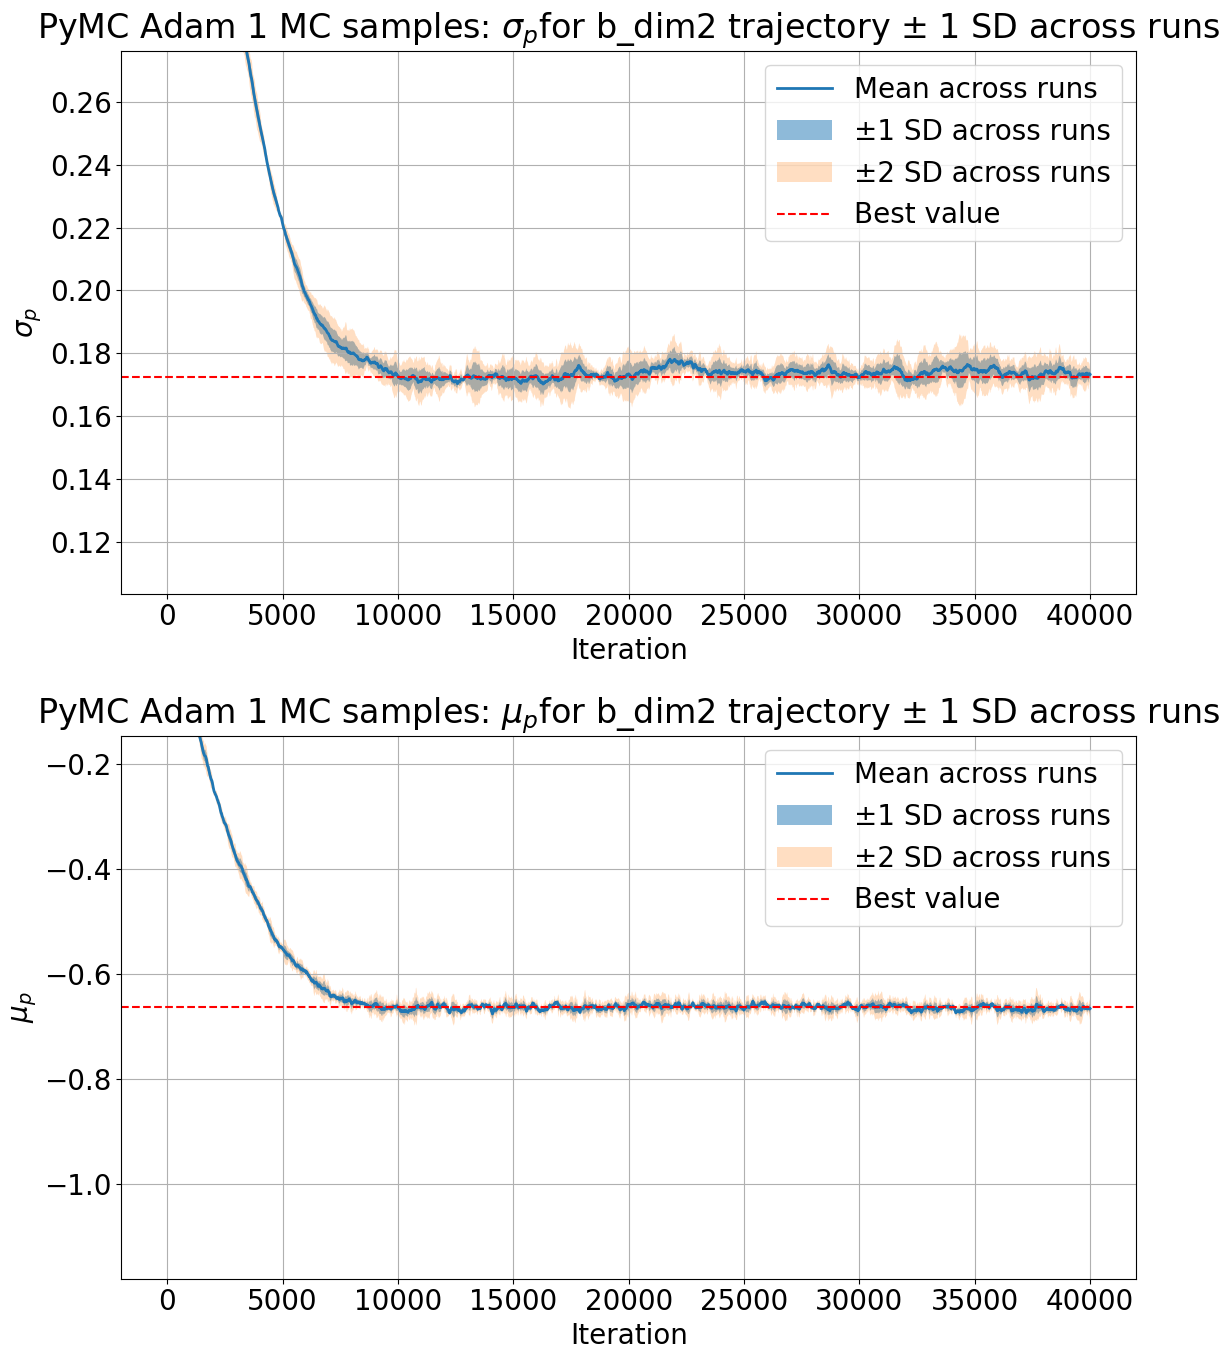

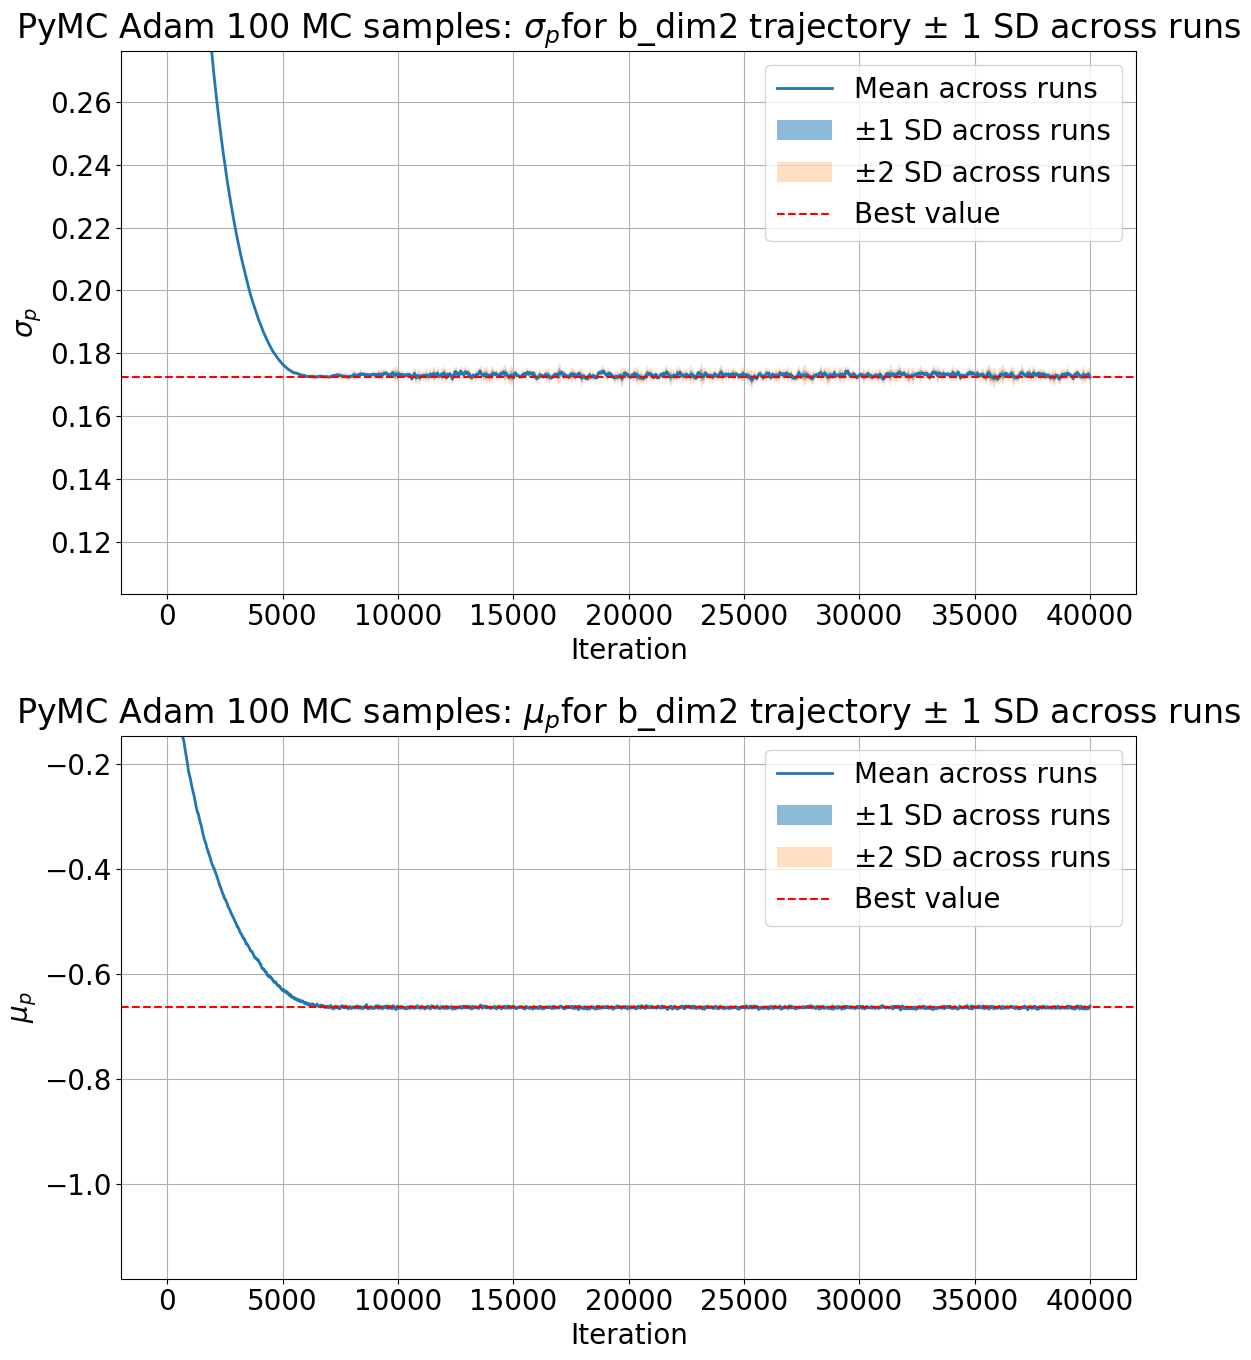

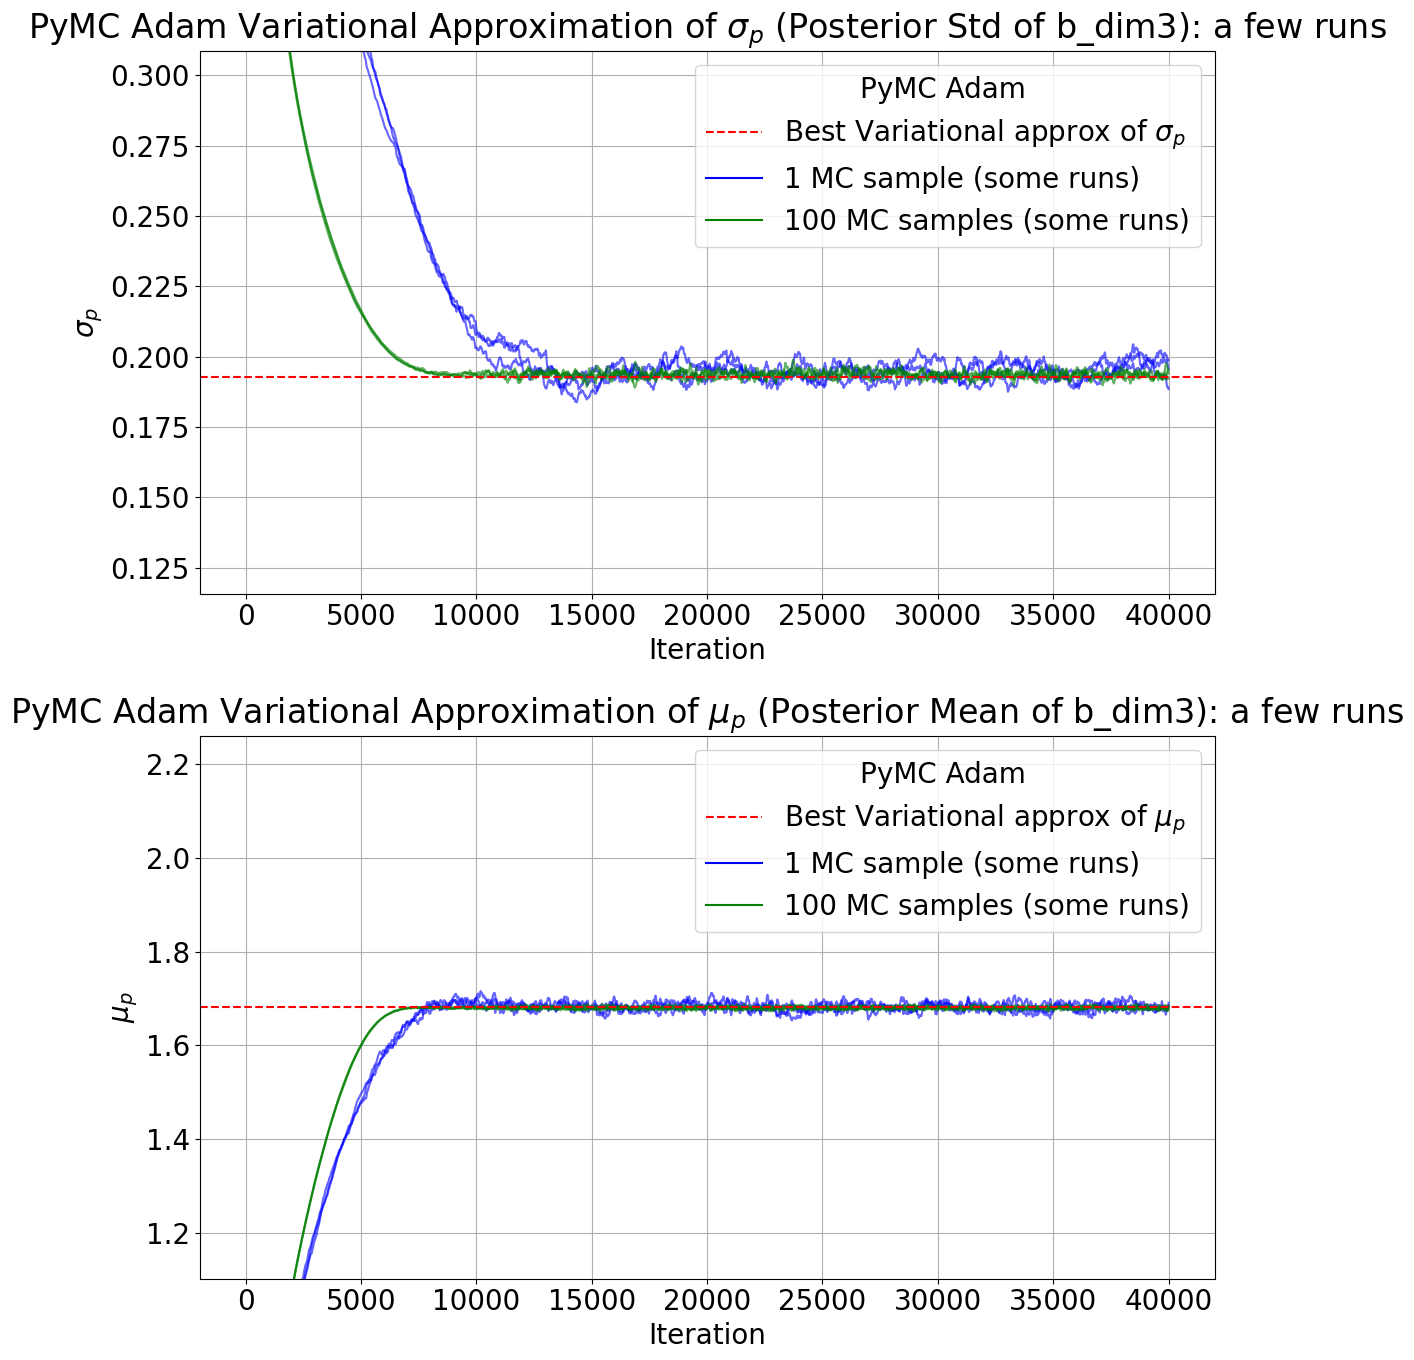

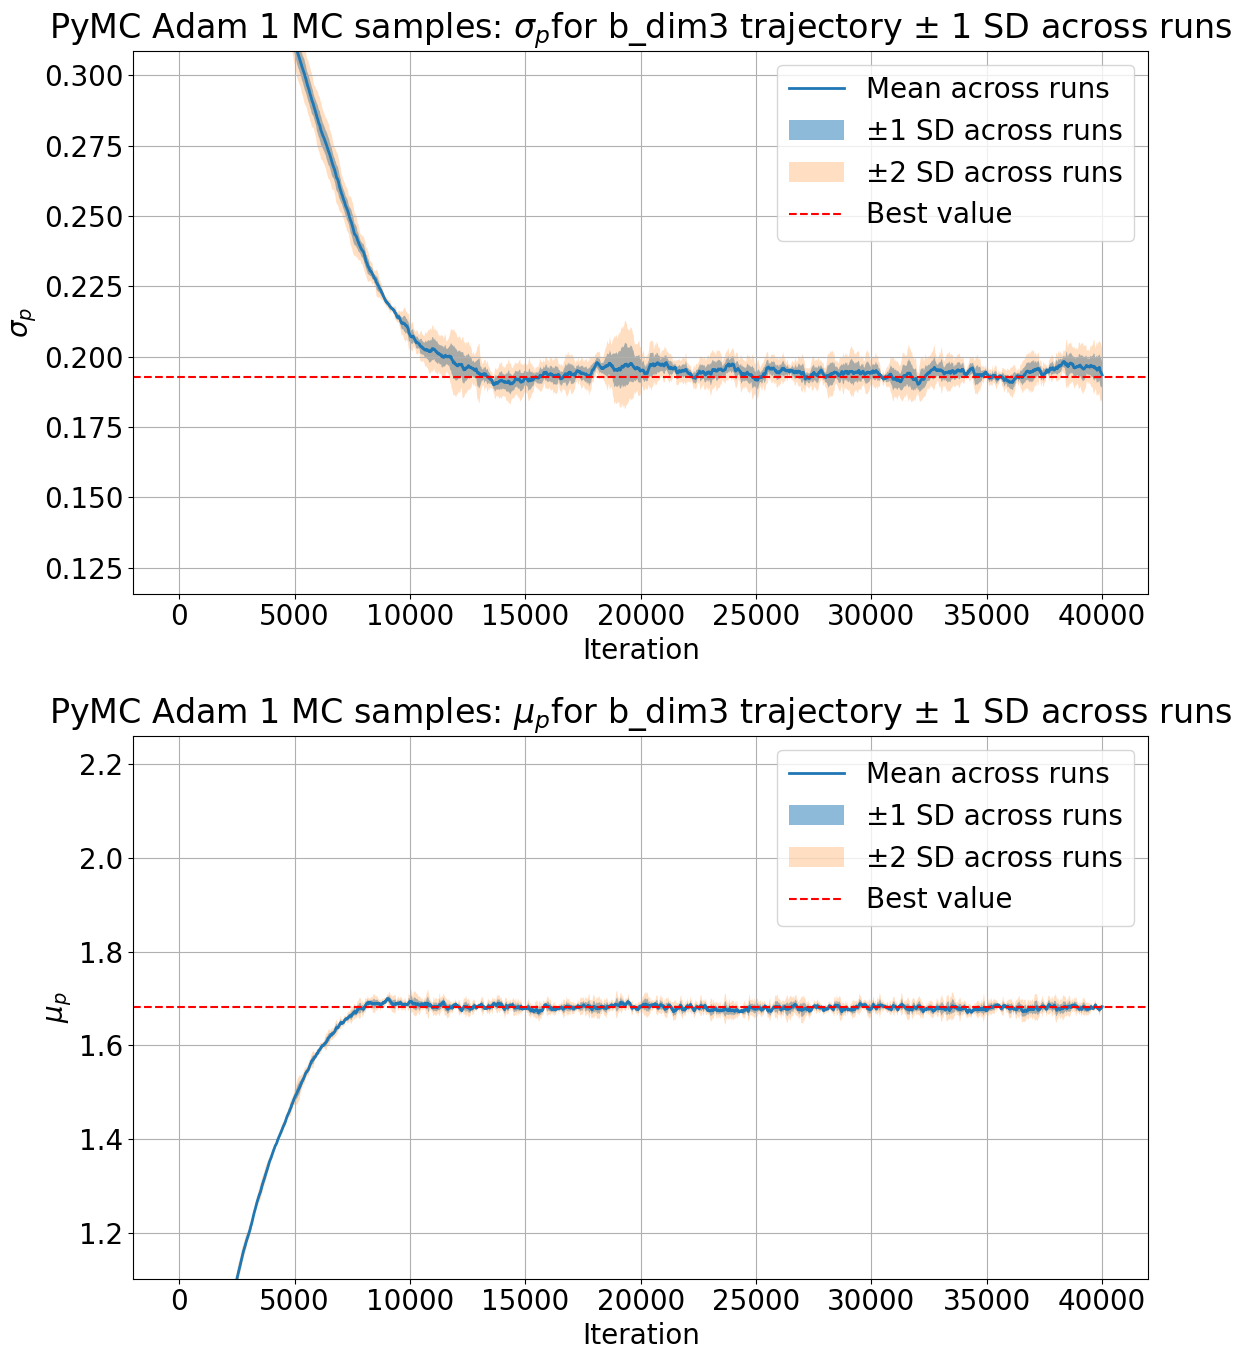

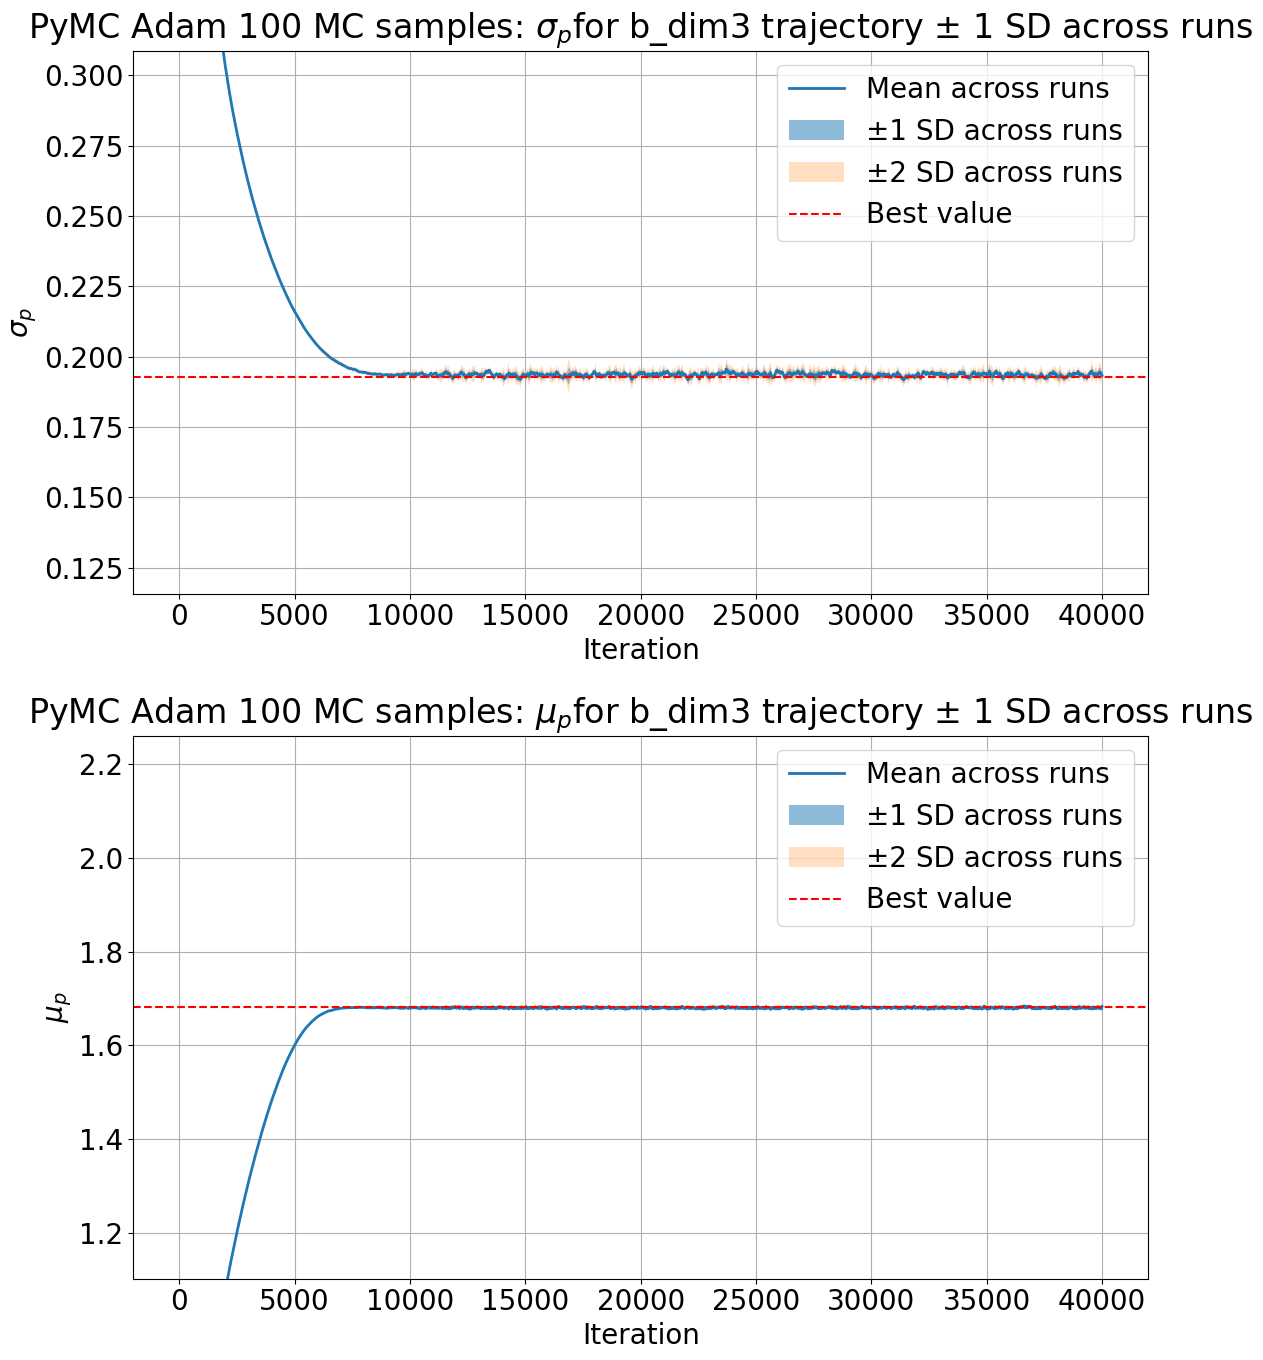

In [14]:

plot_some_dims_multid(
    adam_single_means, adam_single_stds, adam_multi_means, adam_multi_stds,
    best_mean, best_std,
    param_name="b",
    dim=dim,
    which_dims=list(range(dim)),
    k=min(3, n_restarts),
    label_prefix="PyMC Adam ",
    iteration_stride=track_every
)


In [15]:
summary = pd.DataFrame({
    "parameter": labels,
    "default_single_mc_final_mean": single_means[:, -1, :].mean(axis=0),
    "default_single_mc_final_std": single_stds[:, -1, :].mean(axis=0),
    "default_multi_mc_final_mean": multi_means[:, -1, :].mean(axis=0),
    "default_multi_mc_final_std": multi_stds[:, -1, :].mean(axis=0),
    "adam_single_mc_final_mean": adam_single_means[:, -1, :].mean(axis=0),
    "adam_single_mc_final_std": adam_single_stds[:, -1, :].mean(axis=0),
    "adam_multi_mc_final_mean": adam_multi_means[:, -1, :].mean(axis=0),
    "adam_multi_mc_final_std": adam_multi_stds[:, -1, :].mean(axis=0),
    "best_variational_mean": best_reference["mean"].to_numpy(),
    "best_variational_sd": best_reference["sd"].to_numpy(),
})
summary


del single_means, single_stds, multi_means, multi_stds
del adam_single_means, adam_single_stds, adam_multi_means, adam_multi_stds
gc.collect()


158628